In [ ]:
!pip install tsfresh
!pip install eli5

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.2/136.2 kB 6.9 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for eli5: filename=eli5-0.13.0-py2.py3-none-any.whl size=107747 sha256=22863fc16c99d5d1398fe423a23d215da0ac1d16dbdcf28305faf0fa0d33457e
  Stored in directory: /root/.cache/pip/wheels/7b/26/a5/8460416695a992a2966b41caa5338e5e7fcea98c9d032d055c
Successfully built eli5


In [ ]:
!pip install shap

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.4/572.4 kB 11.5 MB/s eta 0:00:00


In [ ]:
# Import libraries
import random
import os
import numpy as np
import pandas as pd
import requests
import pandas_datareader as web

# Date
import datetime as dt
from datetime import date, timedelta, datetime

# EDA
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
import pandas_profiling as pp

# FE
from tsfresh import extract_features, select_features, extract_relevant_features
from tsfresh.utilities.dataframe_functions import impute
from sklearn.inspection import permutation_importance
import eli5
from eli5.sklearn import PermutationImportance
import shap

# Time Series - EDA and Modelling
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA

# Metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Modeling and preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR, LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from prophet import Prophet
import xgboost as xgb
from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")

import pandas_datareader as pdr

In [ ]:
!pip install --upgrade pandas-datareader

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
!pip install yfinance

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
! pip install pycryptodome pycryptodomex
! pip uninstall --yes pandas-datareader
! pip install git+https://github.com/raphi6/pandas-datareader.git@ea66d6b981554f9d0262038aef2106dda7138316

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 69.2 MB/s eta 0:00:00
Found existing installation: pandas-datareader 0.10.0
Uninstalling pandas-datareader-0.10.0:
  Successfully uninstalled pandas-datareader-0.10.0
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Cloning https://github.com/raphi6/pandas-datareader.git (to revision ea66d6b981554f9d0262038aef2106dda7138316) to /tmp/pip-req-build-wtqs5qxb
  Running command git clone --filter=blob:none --quiet https://github.com/raphi6/pandas-datareader.git /tmp/pip-req-build-wtqs5qxb
  Running command git rev-parse -q --verify 'sha^ea66d6b981554f9d0262038aef2106dda7138316'
  Running command git fetch -q https://github.com/raphi6/pandas-datareader.git ea66d6b981554f9d0262038aef2106dda7138316
  Running com

In [ ]:
is_EDA_with_Pandas_Profiling = True # Get Pandas Profiling Report
is_anomalies = True # or Take into account anomalies

In [ ]:
is_Prophet = True
is_ARIMA = True
is_other_ML = True

In [ ]:
# Automatic building ARIMA for Time Series
if is_ARIMA:
    !pip install pmdarima
    import pmdarima as pm

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 20.2 MB/s eta 0:00:00


In [ ]:
# Set random state
def fix_all_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

random_state = 42
fix_all_seeds(random_state)

In [ ]:
# Set main parameters
cryptocurrency = 'BTC'
target = 'Close'
forecasting_days = 10  # forecasting_days > 1

In [ ]:
date_start = dt.datetime(2020, 1, 1)
# date_end = dt.datetime.now()
date_end = dt.datetime(2023, 1, 1)
print(f"Time interval: from {date_start} to {date_end}")

Time interval: from 2020-01-01 00:00:00 to 2023-01-01 00:00:00


In [ ]:
# Download information about cryptocurrencies
df_about = pd.read_csv("/content/about_top_cryptocurrencies_1B_information.csv", sep=";")
display(df_about)

FileNotFoundError: ignored

In [ ]:
def get_part_number(x):
    # Get 1 - st, 2 - nd, 3 - rd, 4.. - th in the first, second, third, ...
    if x==1:
        return 'st'
    elif x==2:
        return 'nd'
    elif x==3:
        return 'rd'
    else: return 'th'

In [ ]:
import yfinance as yf
yf.pdr_override()

In [ ]:
df = yf.download("BTC", date_start,date_end)
df

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-10-01,100.000000,100.000000,100.000000,100.000000,100.000000,0
2020-10-02,100.000000,100.000000,100.000000,100.000000,100.000000,0
2020-10-05,100.029999,100.040001,99.995003,99.995003,99.995003,10725
2020-10-06,100.010002,100.029999,100.010002,100.029999,100.029999,10080
2020-10-07,99.949997,99.959999,99.919998,99.919998,99.919998,6350
...,...,...,...,...,...,...
2022-12-23,90.771004,90.804497,90.760002,90.804497,90.804497,1308
2022-12-27,90.509598,90.509598,90.509598,90.509598,90.509598,15
2022-12-28,90.420998,90.434700,90.420998,90.434700,90.434700,168


In [ ]:
# Correlation coefficients
df.corr() #calculates correlation between the columns

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.999870,0.999564,0.999595,0.999595,0.046610
High,0.999870,1.000000,0.999449,0.999682,0.999682,0.047004
Low,0.999564,0.999449,1.000000,0.999868,0.999868,0.043954
Close,0.999595,0.999682,0.999868,1.000000,1.000000,0.044075
Adj Close,0.999595,0.999682,0.999868,1.000000,1.000000,0.044075
Volume,0.046610,0.047004,0.043954,0.044075,0.044075,1.000000


In [ ]:
# Correlation coefficients
df.corr()['Close'] #calculates corelation of Close with other columns

Open         0.999595
High         0.999682
Low          0.999868
Close        1.000000
Adj Close    1.000000
Volume       0.044075
Name: Close, dtype: float64

In [ ]:
df = df.drop(columns = ["Adj Close"]) #deleting column Adj Close
df

,Open,High,Low,Close,Volume
Date,,,,,
2020-10-01,100.000000,100.000000,100.000000,100.000000,0
2020-10-02,100.000000,100.000000,100.000000,100.000000,0
2020-10-05,100.029999,100.040001,99.995003,99.995003,10725
2020-10-06,100.010002,100.029999,100.010002,100.029999,10080
2020-10-07,99.949997,99.959999,99.919998,99.919998,6350
...,...,...,...,...,...
2022-12-23,90.771004,90.804497,90.760002,90.804497,1308
2022-12-27,90.509598,90.509598,90.509598,90.509598,15
2022-12-28,90.420998,90.434700,90.420998,90.434700,168


<Axes: ylabel='Chart'>

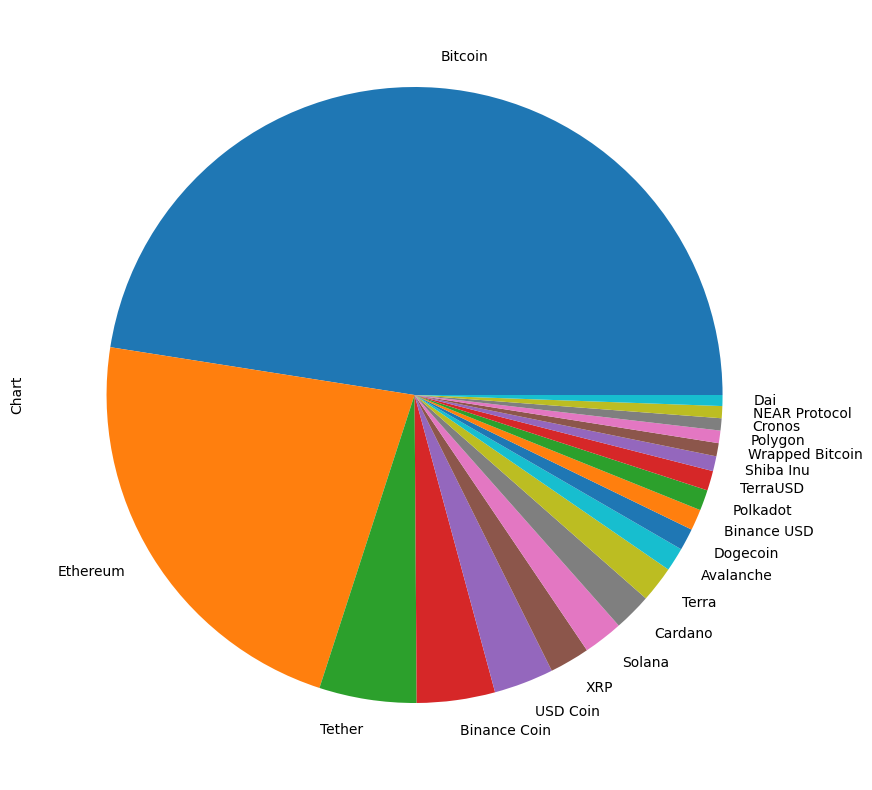

In [ ]:
# Pie chart created from columns 'Market_cap' and 'name'
crypto = pd.Series(df_about.market_cap.head(20).tolist(), index=df_about.name.head(20).tolist(), name="Chart")
crypto.plot.pie(figsize=(10, 10))

In [ ]:
display(df)

,Open,High,Low,Close,Volume
Date,,,,,
2020-10-01,100.000000,100.000000,100.000000,100.000000,0
2020-10-02,100.000000,100.000000,100.000000,100.000000,0
2020-10-05,100.029999,100.040001,99.995003,99.995003,10725
2020-10-06,100.010002,100.029999,100.010002,100.029999,10080
2020-10-07,99.949997,99.959999,99.919998,99.919998,6350
...,...,...,...,...,...
2022-12-23,90.771004,90.804497,90.760002,90.804497,1308
2022-12-27,90.509598,90.509598,90.509598,90.509598,15
2022-12-28,90.420998,90.434700,90.420998,90.434700,168


In [ ]:
#check stationary or not using ADF test; stationary means values don't change over time - desirable property
def check_stationarity(series):

    result = adfuller(series.values)

    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

    if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
        print("\u001b[32mStationary\u001b[0m")
    else:
        print("\x1b[31mNon-stationary\x1b[0m")

In [ ]:
# Stationarity check
check_stationarity(df['Close'])

ADF Statistic: -0.063335
p-value: 0.952970
Critical Values:
	1%: -3.442
	5%: -2.867
	10%: -2.570
Non-stationary


In [ ]:
# Stationarity check of the first difference of time series
check_stationarity(df['Close'].diff().dropna())

ADF Statistic: -4.747197
p-value: 0.000069
Critical Values:
	1%: -3.442
	5%: -2.867
	10%: -2.570
Stationary


In [ ]:
# Stationarity check of the second difference of time series
check_stationarity(df['Close'].diff().diff().dropna())

ADF Statistic: -9.933079
p-value: 0.000000
Critical Values:
	1%: -3.442
	5%: -2.867
	10%: -2.570
Stationary


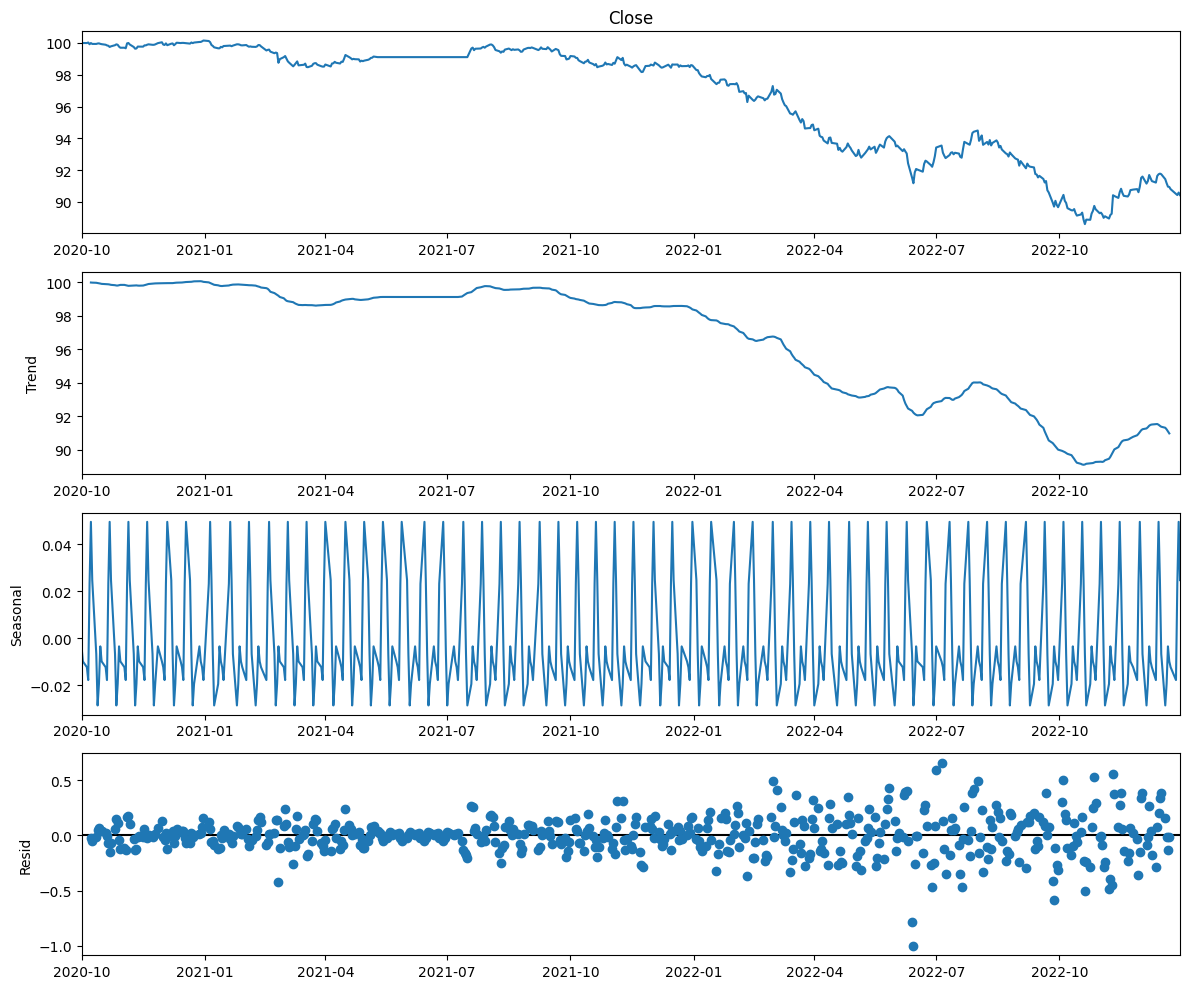

In [ ]:
# Get seasonality of the time series
decomp = seasonal_decompose(df.Close,period=10)
fig = decomp.plot()
fig.set_size_inches((12, 10))
fig.tight_layout()
plt.show()

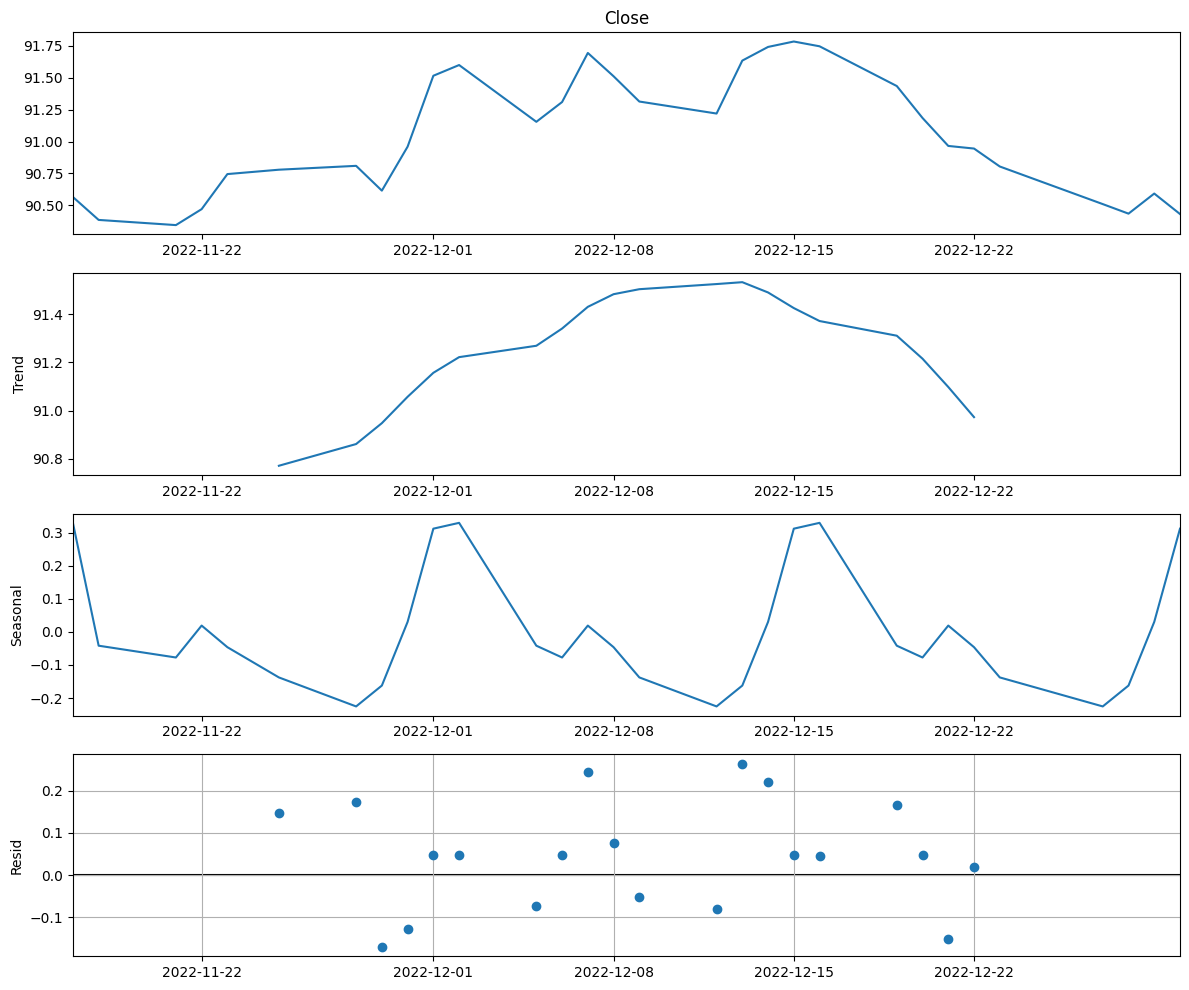

In [ ]:
# Get seasonality of last months (Dec 2022) of the time series
decomposition = seasonal_decompose(df.tail(30).Close,period=10)
fig = decomposition.plot()
fig.set_size_inches((12, 10))
fig.tight_layout()
plt.grid(True)
plt.show()

In [ ]:
def get_tsfresh_features(data):

    data = data.reset_index(drop=False).reset_index(drop=False)

    # Extract features
    extracted_features = extract_features(data, column_id="Date", column_sort="Date")

    # Drop features with NaN
    extracted_features_clean = extracted_features.dropna(axis=1, how='all').reset_index(drop=True)

    # Drop features with constants
    cols_std_zero  = []
    for col in extracted_features_clean.columns:
        if extracted_features_clean[col].std()==0:
            cols_std_zero.append(col)
    extracted_features_clean = extracted_features_clean.drop(columns = cols_std_zero)

    extracted_features_clean['Date'] = data['Date']   # For the merging

    return extracted_features_clean

In [ ]:
%%time
# FE with TSFRESH
extracted_features_clean = get_tsfresh_features(df[['Close']])
extracted_features_clean

Feature Extraction: 100%|██████████| 1134/1134 [00:41<00:00, 27.47it/s]


CPU times: user 43.2 s, sys: 621 ms, total: 43.9 s
Wall time: 44.1 s


,index__sum_values,index__abs_energy,index__median,index__mean,index__root_mean_square,index__maximum,index__absolute_maximum,index__minimum,index__benford_correlation,index__quantile__q_0.1,...,Close__quantile__q_0.7,Close__quantile__q_0.8,Close__quantile__q_0.9,"Close__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)","Close__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)","Close__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)","Close__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)","Close__fft_coefficient__attr_""real""__coeff_0","Close__fft_coefficient__attr_""abs""__coeff_0",Date
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,...,100.000000,100.000000,100.000000,61.329144,38.787956,27.427227,19.393978,100.000000,100.000000,2020-10-01
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.864123,1.0,...,100.000000,100.000000,100.000000,61.329144,38.787956,27.427227,19.393978,100.000000,100.000000,2020-10-02
2,2.0,4.0,2.0,2.0,2.0,2.0,2.0,2.0,0.295657,2.0,...,99.995003,99.995003,99.995003,61.326079,38.786018,27.425856,19.393009,99.995003,99.995003,2020-10-05
3,3.0,9.0,3.0,3.0,3.0,3.0,3.0,3.0,0.062915,3.0,...,100.029999,100.029999,100.029999,61.347542,38.799592,27.435455,19.399796,100.029999,100.029999,2020-10-06
4,4.0,16.0,4.0,4.0,4.0,4.0,4.0,4.0,-0.064614,4.0,...,99.919998,99.919998,99.919998,61.280079,38.756925,27.405285,19.378463,99.919998,99.919998,2020-10-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,562.0,315844.0,562.0,562.0,562.0,562.0,562.0,562.0,-0.145280,562.0,...,90.804497,90.804497,90.804497,55.689620,35.221209,24.905155,17.610604,90.804497,90.804497,2022-12-23
563,563.0,316969.0,563.0,563.0,563.0,563.0,563.0,563.0,-0.145280,563.0,...,90.509598,90.509598,90.509598,55.508761,35.106823,24.824273,17.553412,90.509598,90.509598,2022-12-27
564,564.0,318096.0,564.0,564.0,564.0,564.0,564.0,564.0,-0.145280,564.0,...,90.434700,90.434700,90.434700,55.462827,35.077772,24.803730,17.538886,90.434700,90.434700,2022-12-28
565,565.0,319225.0,565.0,565.0,565.0,565.0,565.0,565.0,-0.145280,565.0,...,90.592300,90.592300,90.592300,55.559482,35.138902,24.846956,17.569451,90.592300,90.592300,2022-12-29


In [ ]:
extracted_features_clean.describe()

,index__sum_values,index__abs_energy,index__median,index__mean,index__root_mean_square,index__maximum,index__absolute_maximum,index__minimum,index__benford_correlation,index__quantile__q_0.1,...,Close__quantile__q_0.6,Close__quantile__q_0.7,Close__quantile__q_0.8,Close__quantile__q_0.9,"Close__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)","Close__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)","Close__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)","Close__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)","Close__fft_coefficient__attr_""real""__coeff_0","Close__fft_coefficient__attr_""abs""__coeff_0"
count,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000,566.000000,567.000000,...,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000
mean,283.000000,106879.666667,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000,0.187411,283.000000,...,96.591763,96.591763,96.591763,96.591763,59.238901,37.465971,26.492442,18.732985,96.591763,96.591763
std,163.823075,95775.337588,163.823075,163.823075,163.823075,163.823075,163.823075,163.823075,0.371877,163.823075,...,3.467979,3.467979,3.467979,3.467979,2.126882,1.345158,0.951171,0.672579,3.467979,3.467979
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.297356,0.000000,...,88.609001,88.609001,88.609001,88.609001,54.343142,34.369621,24.302992,17.184810,88.609001,88.609001
25%,141.500000,20022.500000,141.500000,141.500000,141.500000,141.500000,141.500000,141.500000,-0.064614,141.500000,...,93.426003,93.426003,93.426003,93.426003,57.297368,36.238037,25.624162,18.119019,93.426003,93.426003
50%,283.000000,80089.000000,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000,0.062915,283.000000,...,98.584999,98.584999,98.584999,98.584999,60.461336,38.239106,27.039131,19.119553,98.584999,98.584999
75%,424.500000,180200.500000,424.500000,424.500000,424.500000,424.500000,424.500000,424.500000,0.295657,424.500000,...,99.445000,99.445000,99.445000,99.445000,60.988767,38.572683,27.275006,19.286342,99.445000,99.445000
max,566.000000,320356.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,0.864123,566.000000,...,100.154999,100.154999,100.154999,100.154999,61.424203,38.848077,27.469739,19.424039,100.154999,100.154999


In [ ]:
# Extracted features by TSFRESH with cleaning
extracted_features_clean.columns.tolist()

['index__sum_values',
 'index__abs_energy',
 'index__median',
 'index__mean',
 'index__root_mean_square',
 'index__maximum',
 'index__absolute_maximum',
 'index__minimum',
 'index__benford_correlation',
 'index__quantile__q_0.1',
 'index__quantile__q_0.2',
 'index__quantile__q_0.3',
 'index__quantile__q_0.4',
 'index__quantile__q_0.6',
 'index__quantile__q_0.7',
 'index__quantile__q_0.8',
 'index__quantile__q_0.9',
 'index__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)',
 'index__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)',
 'index__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)',
 'index__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)',
 'index__fft_coefficient__attr_"real"__coeff_0',
 'index__fft_coefficient__attr_"abs"__coeff_0',
 'index__value_count__value_0',
 'index__value_count__value_1',
 'index__range_count__max_1__min_-1',
 'index__count_below__t_0',
 'Close__sum_values',
 'Close__abs_energy',
 'Close__median',
 'Close__mean',
 'Close__root_

In [ ]:
# Get all features
df = pd.merge(df, extracted_features_clean, how='left', on='Date')
df

,Date,Open,High,Low,Close,Volume,index__sum_values,index__abs_energy,index__median,index__mean,...,Close__quantile__q_0.6,Close__quantile__q_0.7,Close__quantile__q_0.8,Close__quantile__q_0.9,"Close__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)","Close__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)","Close__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)","Close__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)","Close__fft_coefficient__attr_""real""__coeff_0","Close__fft_coefficient__attr_""abs""__coeff_0"
0,2020-10-01,100.000000,100.000000,100.000000,100.000000,0,0.0,0.0,0.0,0.0,...,100.000000,100.000000,100.000000,100.000000,61.329144,38.787956,27.427227,19.393978,100.000000,100.000000
1,2020-10-02,100.000000,100.000000,100.000000,100.000000,0,1.0,1.0,1.0,1.0,...,100.000000,100.000000,100.000000,100.000000,61.329144,38.787956,27.427227,19.393978,100.000000,100.000000
2,2020-10-05,100.029999,100.040001,99.995003,99.995003,10725,2.0,4.0,2.0,2.0,...,99.995003,99.995003,99.995003,99.995003,61.326079,38.786018,27.425856,19.393009,99.995003,99.995003
3,2020-10-06,100.010002,100.029999,100.010002,100.029999,10080,3.0,9.0,3.0,3.0,...,100.029999,100.029999,100.029999,100.029999,61.347542,38.799592,27.435455,19.399796,100.029999,100.029999
4,2020-10-07,99.949997,99.959999,99.919998,99.919998,6350,4.0,16.0,4.0,4.0,...,99.919998,99.919998,99.919998,99.919998,61.280079,38.756925,27.405285,19.378463,99.919998,99.919998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,2022-12-23,90.771004,90.804497,90.760002,90.804497,1308,562.0,315844.0,562.0,562.0,...,90.804497,90.804497,90.804497,90.804497,55.689620,35.221209,24.905155,17.610604,90.804497,90.804497
563,2022-12-27,90.509598,90.509598,90.509598,90.509598,15,563.0,316969.0,563.0,563.0,...,90.509598,90.509598,90.509598,90.509598,55.508761,35.106823,24.824273,17.553412,90.509598,90.509598
564,2022-12-28,90.420998,90.434700,90.420998,90.434700,168,564.0,318096.0,564.0,564.0,...,90.434700,90.434700,90.434700,90.434700,55.462827,35.077772,24.803730,17.538886,90.434700,90.434700
565,2022-12-29,90.592300,90.592300,90.592300,90.592300,84,565.0,319225.0,565.0,565.0,...,90.592300,90.592300,90.592300,90.592300,55.559482,35.138902,24.846956,17.569451,90.592300,90.592300


In [ ]:
df.shape

(567, 56)

In [ ]:
def get_add_features(df_feat):

    df_feat['Upper_Shadow'] = df_feat['High'] - np.maximum(df_feat['Close'], df_feat['Open'])
    df_feat['Lower_Shadow'] = np.minimum(df_feat['Close'], df_feat['Open']) - df_feat['Low']

    df_feat['lower_shadow'] = np.minimum(df_feat['Close'], df_feat['Open']) - df_feat['Low']
    df_feat['high2low'] = (df_feat['High'] / df_feat['Low']).replace([np.inf, -np.inf, np.nan], 0.)

    return df_feat

In [ ]:
# FE - add features
df = get_add_features(df)
df

,Date,Open,High,Low,Close,Volume,index__sum_values,index__abs_energy,index__median,index__mean,...,"Close__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)","Close__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)","Close__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)","Close__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)","Close__fft_coefficient__attr_""real""__coeff_0","Close__fft_coefficient__attr_""abs""__coeff_0",Upper_Shadow,Lower_Shadow,lower_shadow,high2low
0,2020-10-01,100.000000,100.000000,100.000000,100.000000,0,0.0,0.0,0.0,0.0,...,61.329144,38.787956,27.427227,19.393978,100.000000,100.000000,0.000000,0.000000,0.000000,1.000000
1,2020-10-02,100.000000,100.000000,100.000000,100.000000,0,1.0,1.0,1.0,1.0,...,61.329144,38.787956,27.427227,19.393978,100.000000,100.000000,0.000000,0.000000,0.000000,1.000000
2,2020-10-05,100.029999,100.040001,99.995003,99.995003,10725,2.0,4.0,2.0,2.0,...,61.326079,38.786018,27.425856,19.393009,99.995003,99.995003,0.010002,0.000000,0.000000,1.000450
3,2020-10-06,100.010002,100.029999,100.010002,100.029999,10080,3.0,9.0,3.0,3.0,...,61.347542,38.799592,27.435455,19.399796,100.029999,100.029999,0.000000,0.000000,0.000000,1.000200
4,2020-10-07,99.949997,99.959999,99.919998,99.919998,6350,4.0,16.0,4.0,4.0,...,61.280079,38.756925,27.405285,19.378463,99.919998,99.919998,0.010002,0.000000,0.000000,1.000400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,2022-12-23,90.771004,90.804497,90.760002,90.804497,1308,562.0,315844.0,562.0,562.0,...,55.689620,35.221209,24.905155,17.610604,90.804497,90.804497,0.000000,0.011002,0.011002,1.000490
563,2022-12-27,90.509598,90.509598,90.509598,90.509598,15,563.0,316969.0,563.0,563.0,...,55.508761,35.106823,24.824273,17.553412,90.509598,90.509598,0.000000,0.000000,0.000000,1.000000
564,2022-12-28,90.420998,90.434700,90.420998,90.434700,168,564.0,318096.0,564.0,564.0,...,55.462827,35.077772,24.803730,17.538886,90.434700,90.434700,0.000000,0.000000,0.000000,1.000152
565,2022-12-29,90.592300,90.592300,90.592300,90.592300,84,565.0,319225.0,565.0,565.0,...,55.559482,35.138902,24.846956,17.569451,90.592300,90.592300,0.000000,0.000000,0.000000,1.000000


In [ ]:
# Synthesis dataframe with anomalous dates for Facebook Prophet
if is_anomalies:
    anomalous_dates = ['2021-01-08', '2021-01-27', '2021-04-13', '2021-07-20',
                       '2021-09-06', '2021-09-29', '2021-11-08', '2021-12-17']
    holidays_df = pd.DataFrame(columns = ['ds', 'lower_window', 'upper_window', 'prior_scale'])
    holidays_df['ds'] = anomalous_dates
    holidays_df['holiday'] = 'anomalous_dates'
    holidays_df['lower_window'] = 0
    holidays_df['upper_window'] = 0
    holidays_df['prior_scale'] = 10
    display(holidays_df)

,ds,lower_window,upper_window,prior_scale,holiday
0,2021-01-08,0,0,10,anomalous_dates
1,2021-01-27,0,0,10,anomalous_dates
2,2021-04-13,0,0,10,anomalous_dates
3,2021-07-20,0,0,10,anomalous_dates
4,2021-09-06,0,0,10,anomalous_dates
5,2021-09-29,0,0,10,anomalous_dates
6,2021-11-08,0,0,10,anomalous_dates
7,2021-12-17,0,0,10,anomalous_dates


In [ ]:
# Add new anomalous dates
if is_anomalies:
    anomalous_dates_diff = anomalous_dates.copy()
    anomalous_dates_diff.append('2021-02-08')
    anomalous_dates_diff.append('2021-05-12')
    anomalous_dates_diff.append('2021-09-07')
    print(anomalous_dates_diff)

['2021-01-08', '2021-01-27', '2021-04-13', '2021-07-20', '2021-09-06', '2021-09-29', '2021-11-08', '2021-12-17', '2021-02-08', '2021-05-12', '2021-09-07']


In [ ]:
# Illustration of number transformations in the columns:
# "Close" -> "Close_diff" -> "Target" -> "Close_diff_pred" -> "Close_pred"
# Get target and the result of the forecasting
forecasting_days_example = 3
df_example = pd.DataFrame({'Close':[1, 2, 4, 8, 15, 25], 'Day': [0, 1, 2, 3, 4, 5]})
df_example['Close_diff'] = df_example['Close'].diff()
df_example['target'] = df_example['Close_diff'].shift(-forecasting_days_example)
df_example['target_pred'] = df_example['target'].copy()   # Ideal forecasting result
print(f'Simulation of the result of ideal forecasting the "target_pred" for {forecasting_days_example} days')
display(df_example[['Day', 'Close', 'Close_diff', 'target', 'target_pred']])

# Get inverse target
print('\nSimulation of the recovering predicted values "Close_pred" from the "target_pred"')
df_example['Close_diff_pred_shifted'] = df_example['target_pred'].shift(forecasting_days_example)

# Let's create an intermediate feature to make it easier to explain the transformation
temp_column_name = f'Close_diff_pred_shifted_with_Close'  # Intermediate feature for transformations
df_example[temp_column_name] = df_example['Close_diff_pred_shifted'].copy()
df_example.loc[forecasting_days_example, temp_column_name] = df_example.loc[forecasting_days_example,'Close']
df_example['Close_pred'] = np.concatenate((df_example['Close'].tolist()[:forecasting_days_example],
                                           np.cumsum(df_example[temp_column_name].values[forecasting_days_example:], dtype=float)))
df_example['Close_pred'] = df_example['Close_pred'].astype('int')
display(df_example[['Day', 'Close', 'Close_diff', 'target', 'target_pred', 'Close_diff_pred_shifted', temp_column_name, 'Close_pred']])

Simulation of the result of ideal forecasting the "target_pred" for 3 days


,Day,Close,Close_diff,target,target_pred
0,0,1,NaN,4.0,4.0
1,1,2,1.0,7.0,7.0
2,2,4,2.0,10.0,10.0
3,3,8,4.0,NaN,NaN
4,4,15,7.0,NaN,NaN
5,5,25,10.0,NaN,NaN



Simulation of the recovering predicted values "Close_pred" from the "target_pred"


,Day,Close,Close_diff,target,target_pred,Close_diff_pred_shifted,Close_diff_pred_shifted_with_Close,Close_pred
0,0,1,NaN,4.0,4.0,NaN,NaN,1
1,1,2,1.0,7.0,7.0,NaN,NaN,2
2,2,4,2.0,10.0,10.0,NaN,NaN,4
3,3,8,4.0,NaN,NaN,4.0,8.0,8
4,4,15,7.0,NaN,NaN,7.0,7.0,15
5,5,25,10.0,NaN,NaN,10.0,10.0,25


In [ ]:
def cut_data(df, y, num_start, num_end):
    # Cutting dataframe df and array or list for [num_start, num_end-1]
    df2 = df[num_start:(num_end+1)]
    y2 = y[num_start:(num_end+1)] if y is not None else None
    return df2, y2

In [ ]:
def get_target_mf(df, forecasting_days, col='Close'):
    # Get target as difference of the df[col]
    # Returns target which is shifted for forecasting_days days in the dataframe df
    # "Close" -> "Close_diff" -> "Target"
    col_diff = f"{col}_diff"
    df[col_diff] = df['Close'].diff()
    df['target'] = df[col_diff].shift(-forecasting_days)
    df = df.drop(columns=[col_diff]).dropna()

    return df

In [ ]:
def get_train_valid_test_ts(df, forecasting_days, target='Close'):
    # Get training, validation and test datasets with target for Time Series models

    # Data prepairing
    df = df.dropna(how="any").reset_index(drop=True)
    df = df[['Date', 'Close']]
    df.columns = ['ds', 'y']
    y = None

    # Data smoothing
#     df.index = df.ds
#     df = df.drop(columns=['ds'])
#     df['y'] = df['y'].rolling(7).mean()
#     df = df.dropna().reset_index(drop=False)

    N = len(df)
    train, _ = cut_data(df, y, 0, N-2*forecasting_days-1)
    valid, _ = cut_data(df, y, N-2*forecasting_days, N-forecasting_days-1)
    test, _ = cut_data(df, y, N-forecasting_days, N)

    # Train+valid - for optimal model training
    train_valid = pd.concat([train, valid])

    print(f'Origin dataset has {len(df)} rows and {len(df.columns)} features')
    print(f'Get training dataset with {len(train)} rows')
    print(f'Get validation dataset with {len(valid)} rows')
    print(f'Get test dataset with {len(test)} rows')

    return train, valid, test, train_valid

In [ ]:
def get_train_valid_test_mf(df, forecasting_days, target='target'):
    # Get training, validation and test datasets with target for multi-features ML models

    df = df.drop(columns = ['Date']).dropna(how="any").reset_index(drop=True)

    # Save and drop target
    y = df.pop(target)

    # Get starting points for the recovering "Close" from "Close_diff_shigted"
    N = len(df)
    #print(f"Total - {N}, Valid start index = {N-forecasting_days-1}, Test start index = {N-1}")
    start_points = {'valid_start_point' : df.loc[N-forecasting_days-1, 'Close'],
                    'test_start_point' : df.loc[N-1, 'Close']}

    # Standartization data
    scaler = StandardScaler()
    df = pd.DataFrame(scaler.fit_transform(df), columns = df.columns)


    train, ytrain = cut_data(df.copy(), y, 0, N-2*forecasting_days-1)
    valid, yvalid = cut_data(df.copy(), y, N-2*forecasting_days, N-forecasting_days-1)
    test, ytest = cut_data(df.copy(), y, N-forecasting_days, N)


    # Train+valid - for optimal model training
    train_valid = pd.concat([train, valid])
    y_train_valid = pd.concat([ytrain, yvalid])

    print(f'Origin dataset has {len(df)} rows and {len(df.columns)} features')
    print(f'Get training dataset with {len(train)} rows')
    print(f'Get validation dataset with {len(valid)} rows')
    print(f'Get test dataset with {len(test)} rows')

    return train, ytrain, valid, yvalid, test, ytest, train_valid, y_train_valid, start_points

In [ ]:
def calc_metrics(type_score, list_true, list_pred):
    # Calculation score with type=type_score for list_true and list_pred
    if type_score=='r2_score':
        score = r2_score(list_true, list_pred)
    elif type_score=='rmse':
        score = mean_squared_error(list_true, list_pred, squared=False)
    elif type_score=='mape':
        score = mean_absolute_percentage_error(list_true, list_pred)
    return score

In [ ]:
def result_add_metrics(result, n, y_true, y_pred):
    # Calculation and addition metrics into dataframe result[n,:]

    result.loc[n,'r2_score'] = calc_metrics('r2_score', y_true, y_pred)
    result.loc[n,'rmse'] = calc_metrics('rmse', y_true, y_pred)      # in coins
    result.loc[n,'mape'] = 100*calc_metrics('mape', y_true, y_pred)  # in %

    return result

In [ ]:
# Results of all models
result = pd.DataFrame(columns = ['name_model', 'type_data', 'r2_score', 'rmse', 'mape', 'params', 'ypred'])

In [ ]:
# Modeling 2021 year only
if is_Prophet:
    df2 = df[df.Date.dt.year == 2021]
    display(df2)

,Date,Open,High,Low,Close,Volume,index__sum_values,index__abs_energy,index__median,index__mean,...,"Close__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)","Close__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)","Close__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)","Close__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)","Close__fft_coefficient__attr_""real""__coeff_0","Close__fft_coefficient__attr_""abs""__coeff_0",Upper_Shadow,Lower_Shadow,lower_shadow,high2low
64,2021-01-04,100.122902,100.122902,100.122902,100.122902,2,64.0,4096.0,64.0,64.0,...,61.404519,38.835627,27.460936,19.417814,100.122902,100.122902,0.000000,0.000000,0.000000,1.000000
65,2021-01-05,100.059998,100.079903,100.050003,100.050003,751,65.0,4225.0,65.0,65.0,...,61.359810,38.807351,27.440941,19.403676,100.050003,100.050003,0.019905,0.000000,0.000000,1.000299
66,2021-01-06,99.859001,99.874603,99.859001,99.874603,109,66.0,4356.0,66.0,66.0,...,61.252239,38.739318,27.392834,19.369659,99.874603,99.874603,0.000000,0.000000,0.000000,1.000156
67,2021-01-07,99.830002,99.830002,99.785004,99.813698,2099,67.0,4489.0,67.0,67.0,...,61.214886,38.715694,27.376129,19.357847,99.813698,99.813698,0.000000,0.028694,0.028694,1.000451
68,2021-01-08,99.724998,99.724998,99.724998,99.724998,3,68.0,4624.0,68.0,68.0,...,61.160488,38.681289,27.351802,19.340644,99.724998,99.724998,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311,2021-12-27,98.540001,98.550003,98.269997,98.550003,2513,311.0,96721.0,311.0,311.0,...,60.439873,38.225532,27.029533,19.112766,98.550003,98.550003,0.000000,0.270004,0.270004,1.002849
312,2021-12-28,98.610001,98.610001,98.589996,98.589996,160,312.0,97344.0,312.0,312.0,...,60.464401,38.241045,27.040502,19.120522,98.589996,98.589996,0.000000,0.000000,0.000000,1.000203
313,2021-12-29,98.470001,98.485001,98.470001,98.485001,402,313.0,97969.0,313.0,313.0,...,60.400008,38.200319,27.011705,19.100160,98.485001,98.485001,0.000000,0.000000,0.000000,1.000152
314,2021-12-30,98.609497,98.609497,98.609497,98.609497,83,314.0,98596.0,314.0,314.0,...,60.476360,38.248609,27.045851,19.124304,98.609497,98.609497,0.000000,0.000000,0.000000,1.000000


In [ ]:
# Get datasets
if is_Prophet:
    train_ts, valid_ts, test_ts, train_valid_ts = get_train_valid_test_ts(df2.copy(), forecasting_days, target='Close')

    if not is_anomalies:
        holidays_df = None

Origin dataset has 252 rows and 2 features
Get training dataset with 232 rows
Get validation dataset with 10 rows
Get test dataset with 10 rows


In [ ]:
def prophet_modeling(result,
                     cryptocurrency,
                     train,
                     test,
                     holidays_df,
                     period_days,
                     fourier_order_seasonality,
                     forecasting_period,
                     name_model,
                     type_data):
    # Performs FB Prophet model training for given train dataset, holidays_df and seasonality_mode
    # Performs forecasting with period by this model, visualization and error estimation
    # df - dataframe with real data in the forecasting_period
    # can be such combinations of parameters: train=train, test=valid or train=train_valid, test=test
    # Save results into dataframe result

    # Build Prophet model with parameters and structure
    model = Prophet(daily_seasonality=False,
                    weekly_seasonality=False,
                    yearly_seasonality=False,
                    changepoint_range=1,
                    changepoint_prior_scale = 0.5,
                    holidays=holidays_df,
                    seasonality_mode = 'multiplicative'
                   )
    model.add_seasonality(name='seasonality', period=period_days,
                          fourier_order=fourier_order_seasonality,
                          mode = 'multiplicative', prior_scale = 0.5)
    # Training model for df
    model.fit(train)

    # Make a forecast
    future = model.make_future_dataframe(periods = forecasting_period)
    forecast = model.predict(future)

    # Draw plot of the values with forecasting data
    figure = model.plot(forecast, xlabel = 'Date', ylabel = f"{name_model} for {cryptocurrency}")

    # Draw plot with the components (trend and seasonalities) of the forecasts
    figure_component = model.plot_components(forecast)

    # Ouput the prediction for the next time on forecasted_days
    #forecast[['yhat_lower', 'yhat', 'yhat_upper']] = forecast[['yhat_lower', 'yhat', 'yhat_upper']].round(1)
    #forecast[['ds', 'yhat_lower', 'yhat', 'yhat_upper']].tail(forecasting_period)

    # Forecasting data by the model
    ypred = forecast['yhat'][-forecasting_period:]
    #print(ypred)
    # Save results
    n = len(result)
    result.loc[n,'name_model'] = f"Prophet_{name_model}"
    result.loc[n,'type_data'] = type_data
    result.at[n,'params'] = [period_days]+[fourier_order_seasonality]
    result.at[n,'ypred'] = ypred
    #result = result_add_metrics(result, n, test['y'], y_pred)

    return result, ypred

DEBUG:cmdstanpy:input tempfile: /tmp/tmp7hoeoru_/s7h37798.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7hoeoru_/kk9c8rn_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.9/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=83895', 'data', 'file=/tmp/tmp7hoeoru_/s7h37798.json', 'init=/tmp/tmp7hoeoru_/kk9c8rn_.json', 'output', 'file=/tmp/tmp7hoeoru_/prophet_model0uxpe8ie/prophet_model-20230410130838.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:08:38 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:08:38 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7hoeoru_/fzq3eais.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7hoeoru_/bxik3n0d.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/l

CPU times: user 5.09 s, sys: 2.83 s, total: 7.91 s
Wall time: 6.44 s


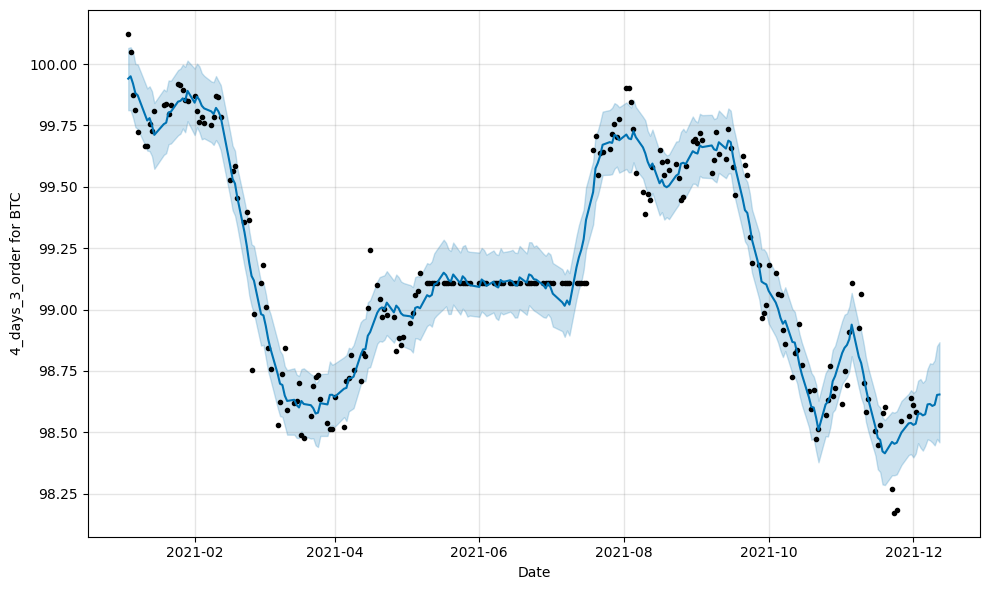

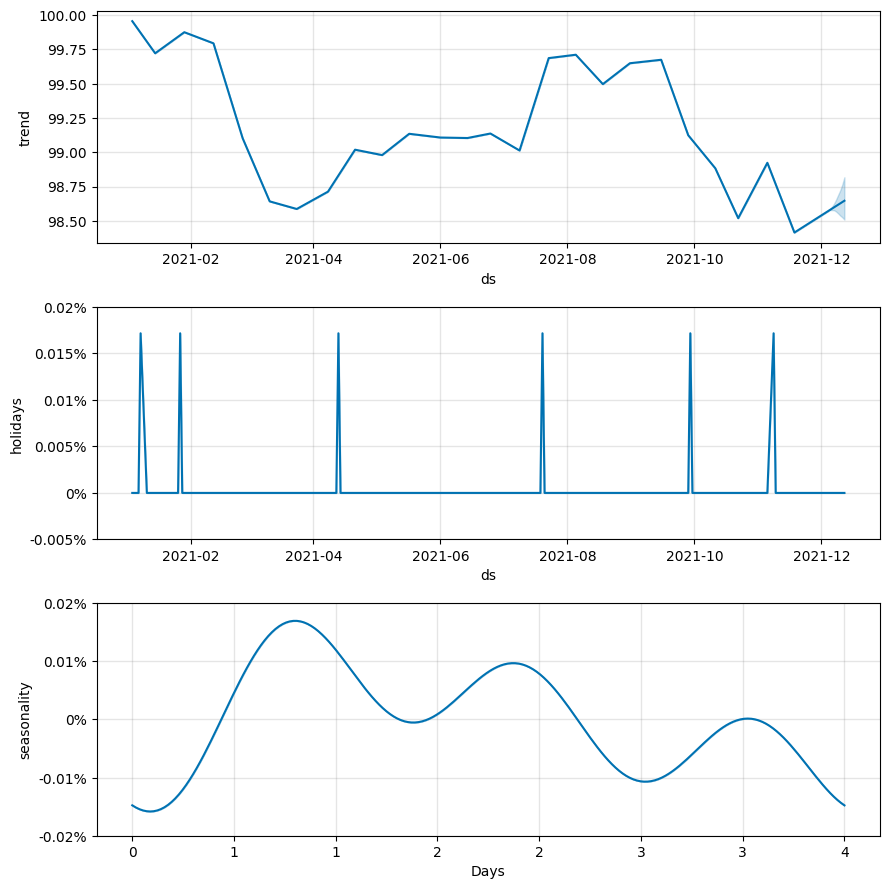

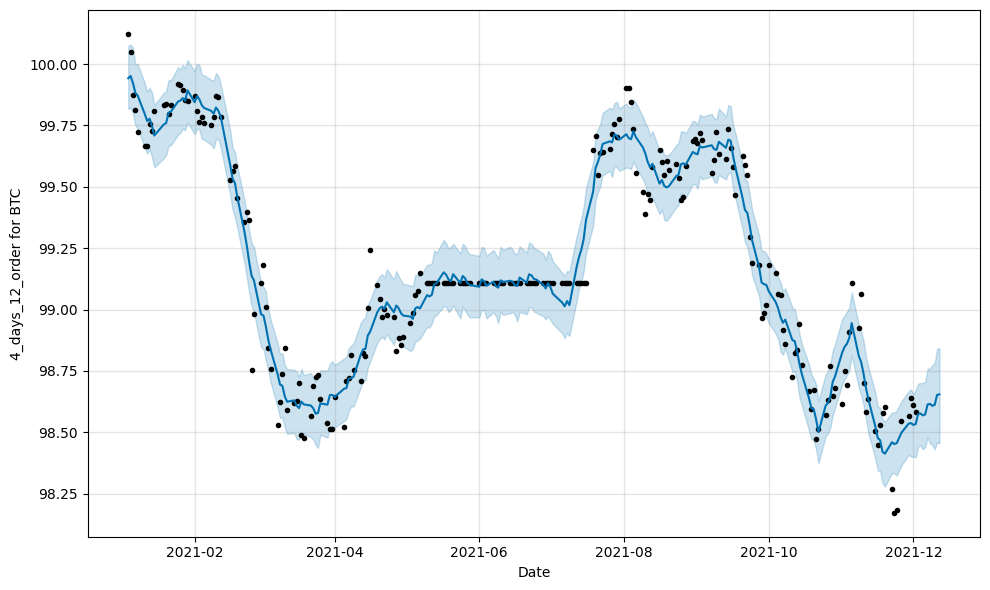

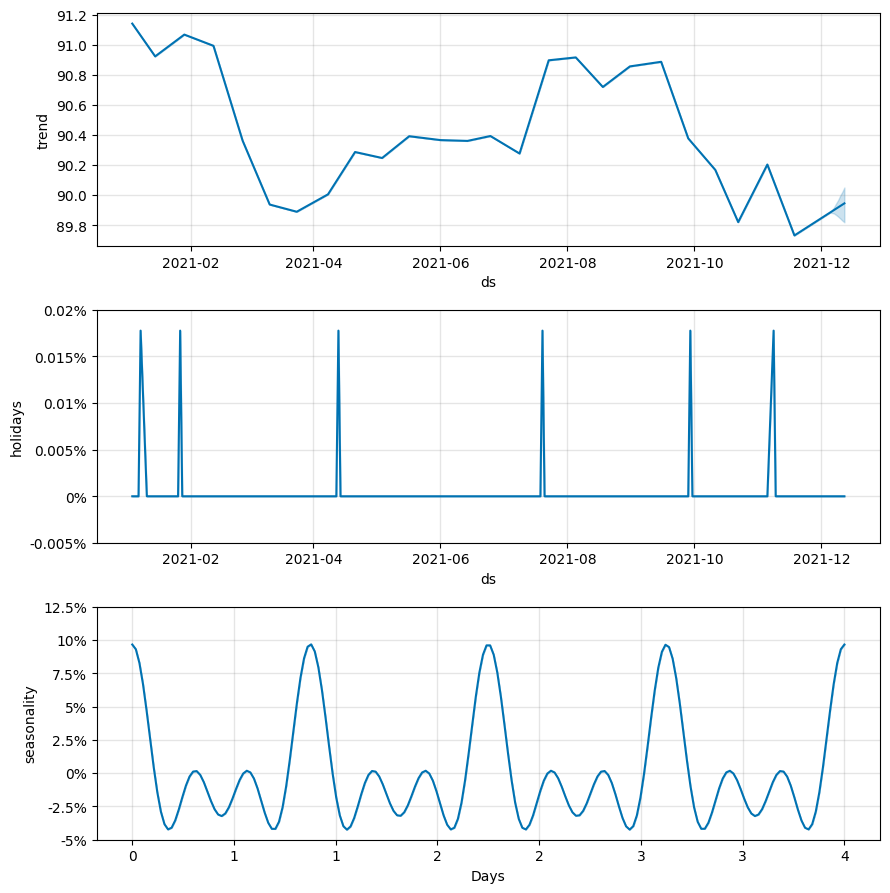

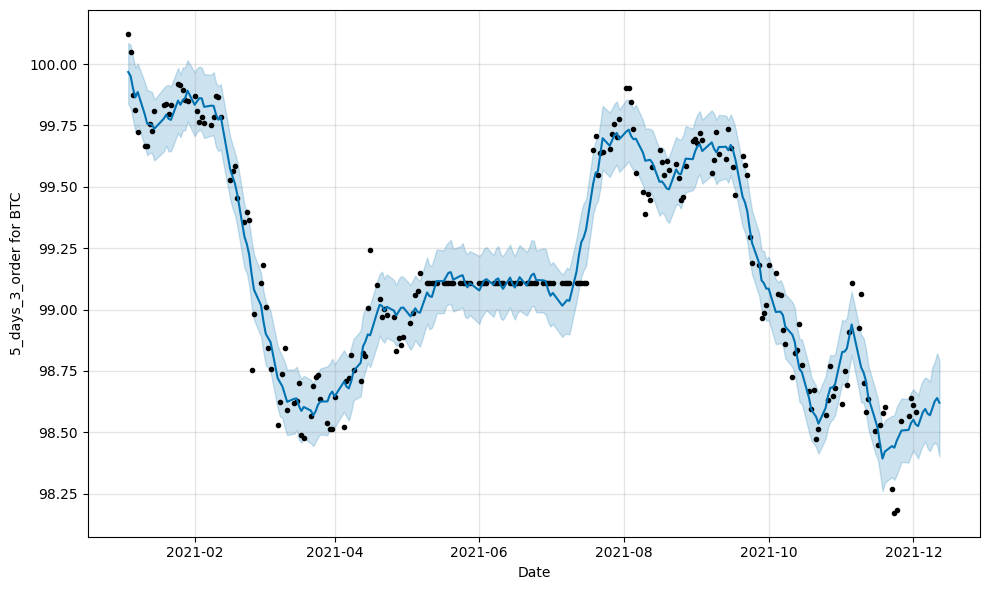

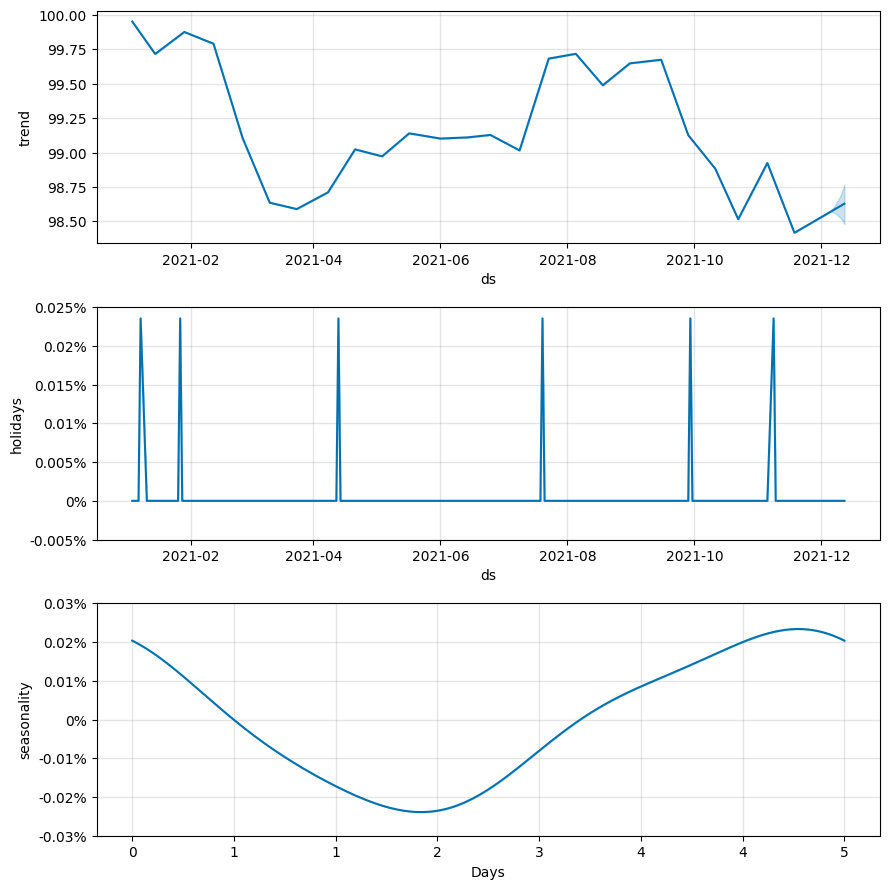

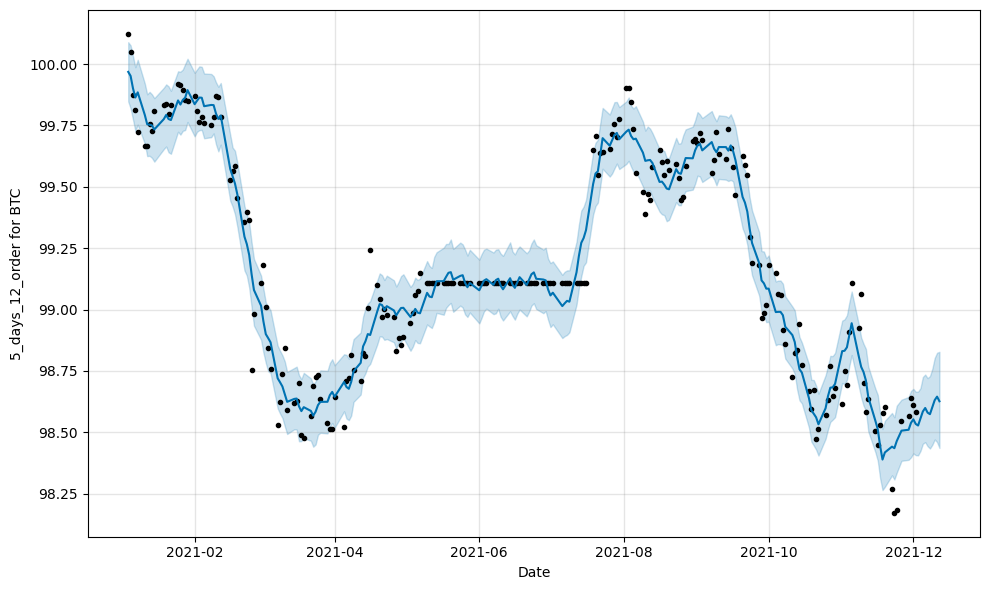

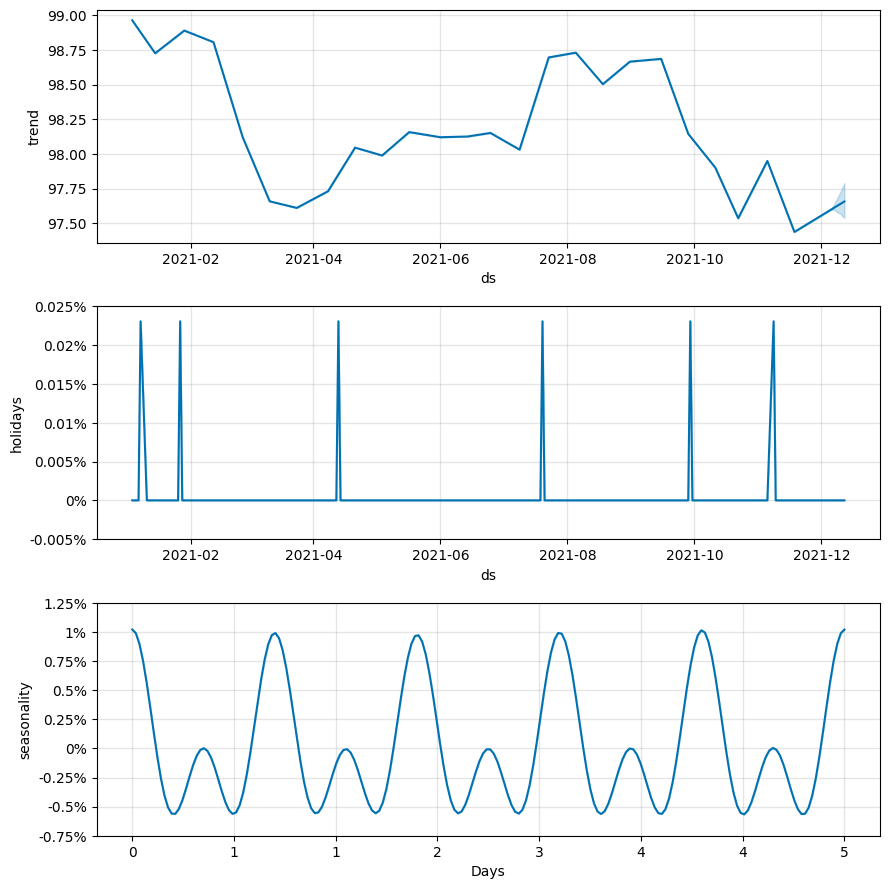

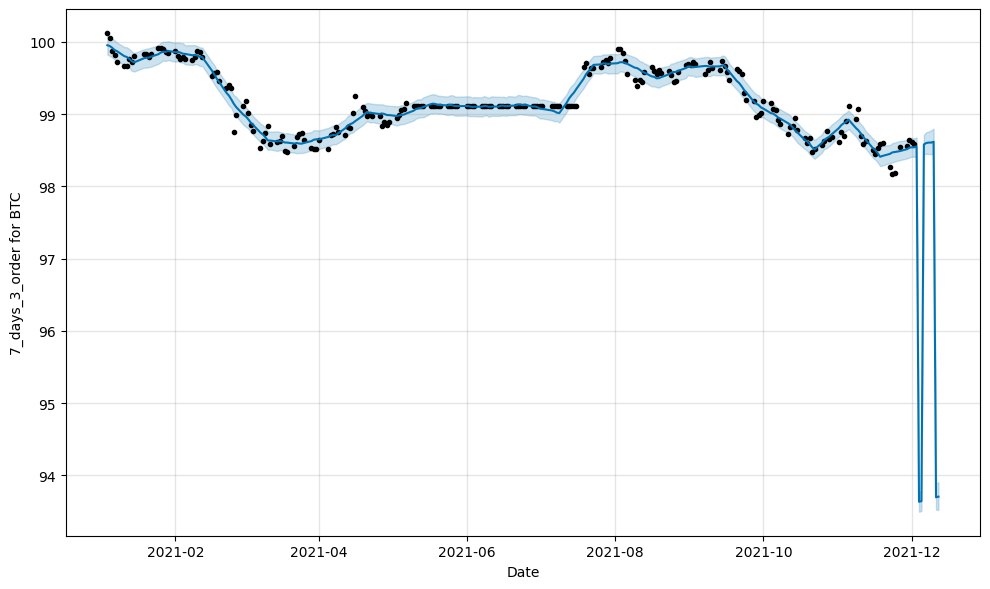

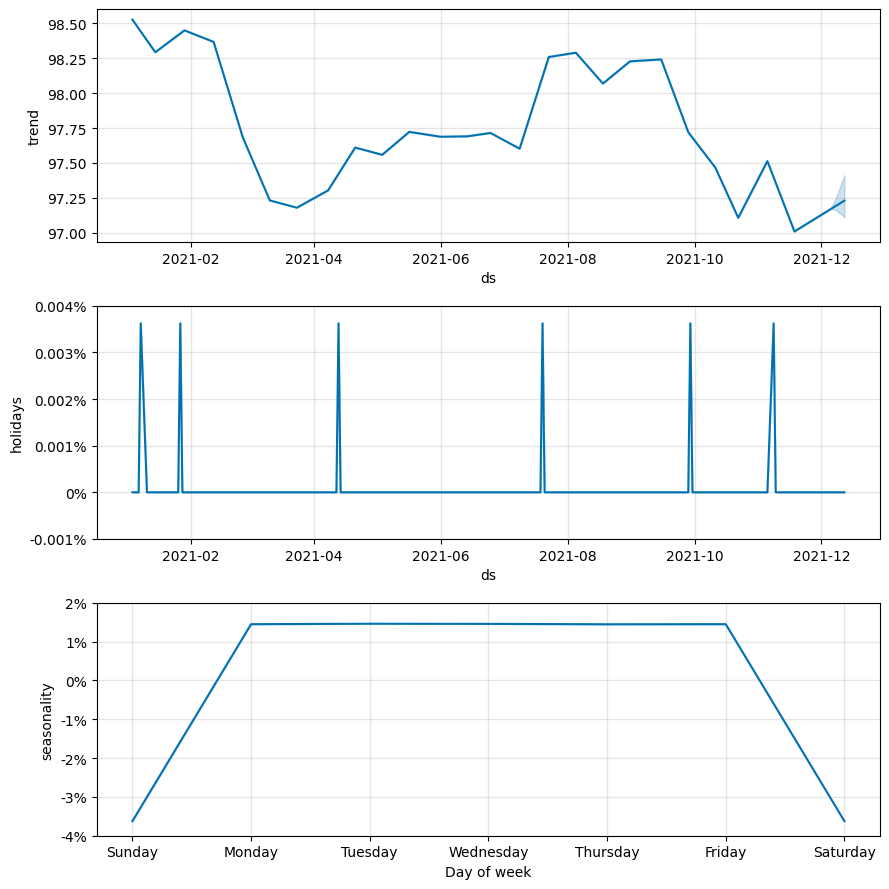

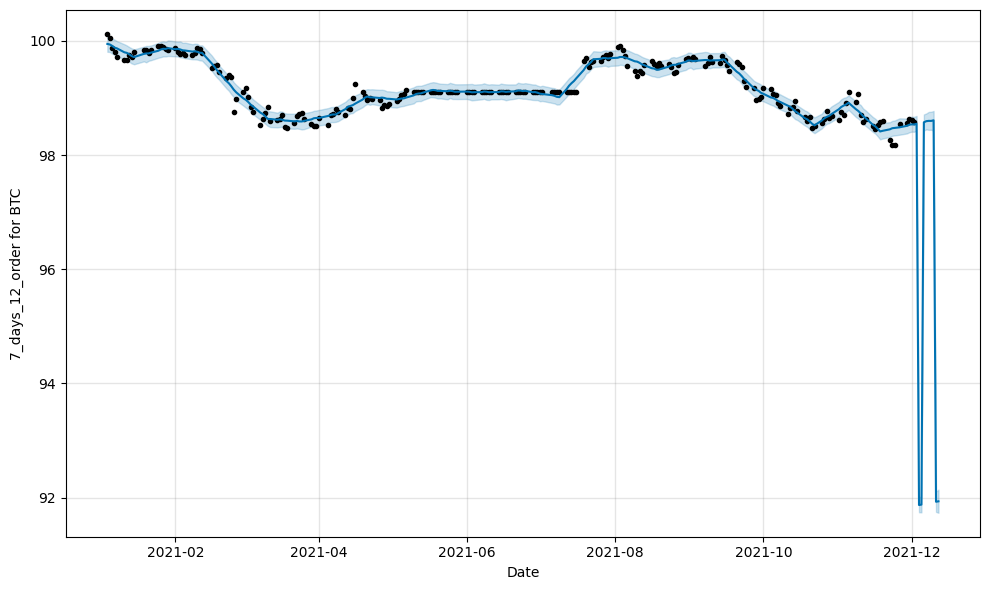

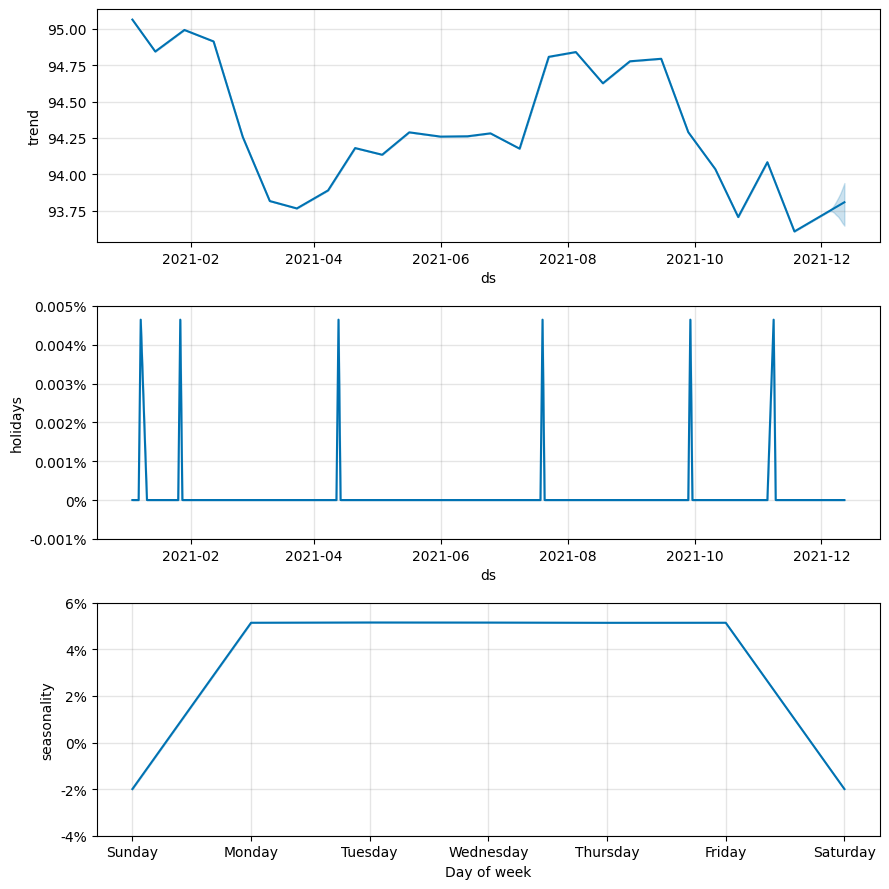

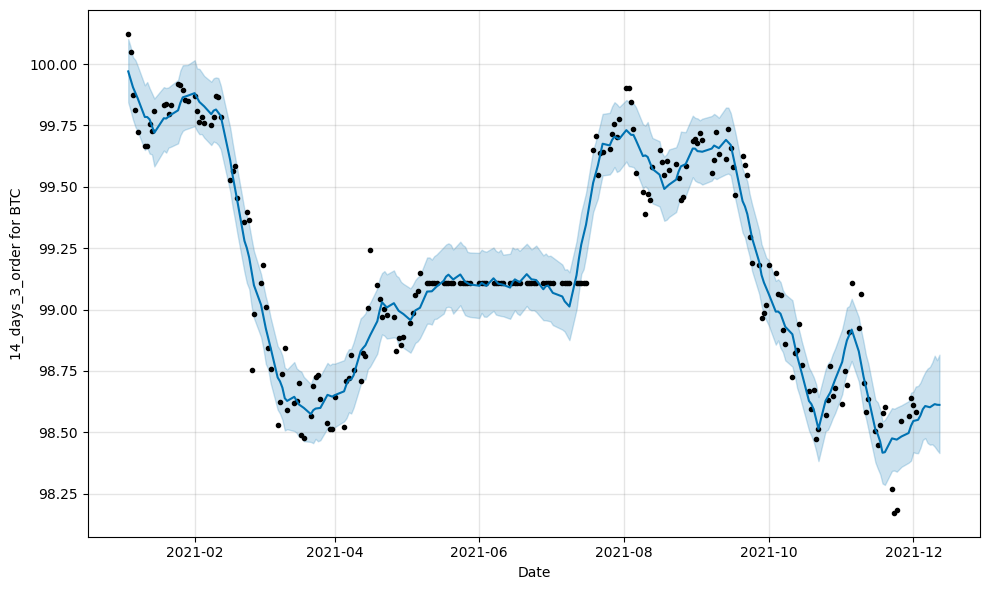

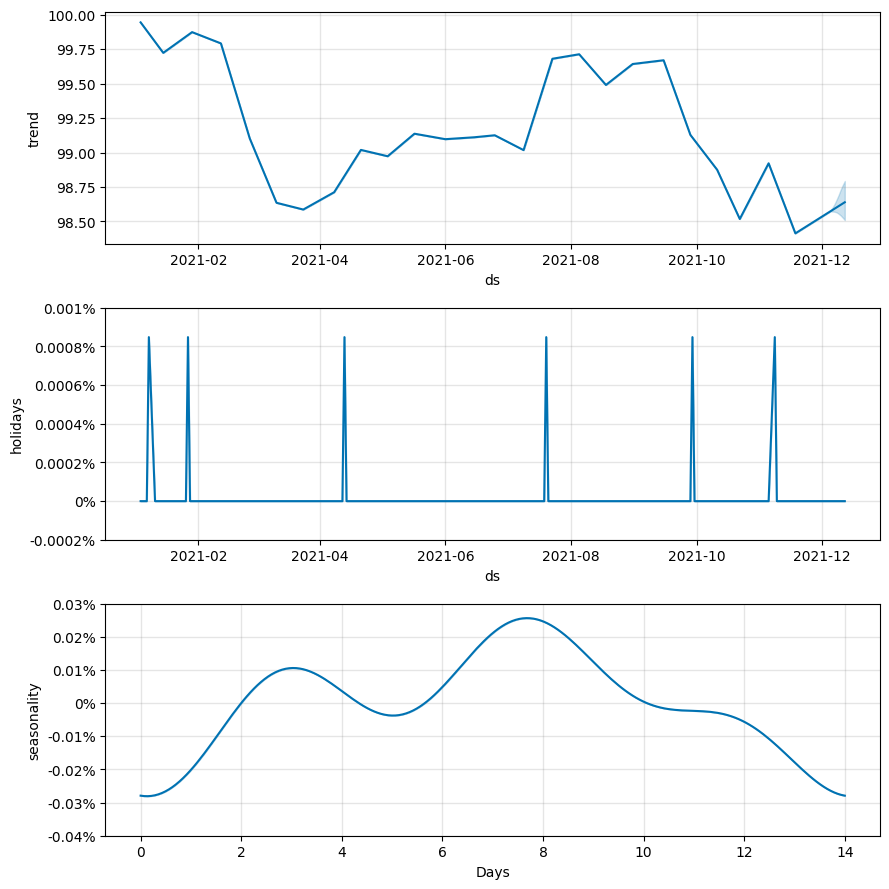

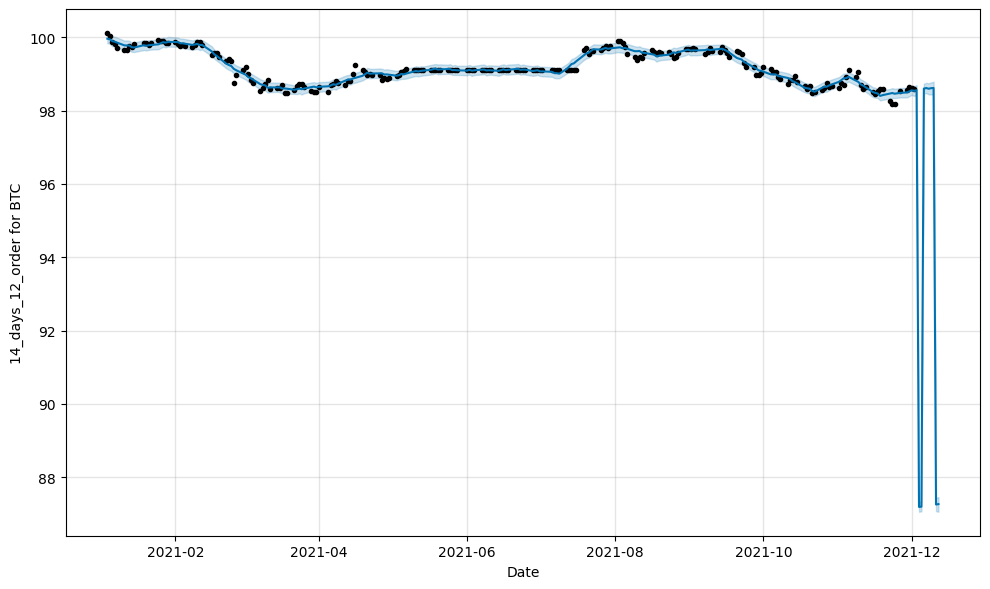

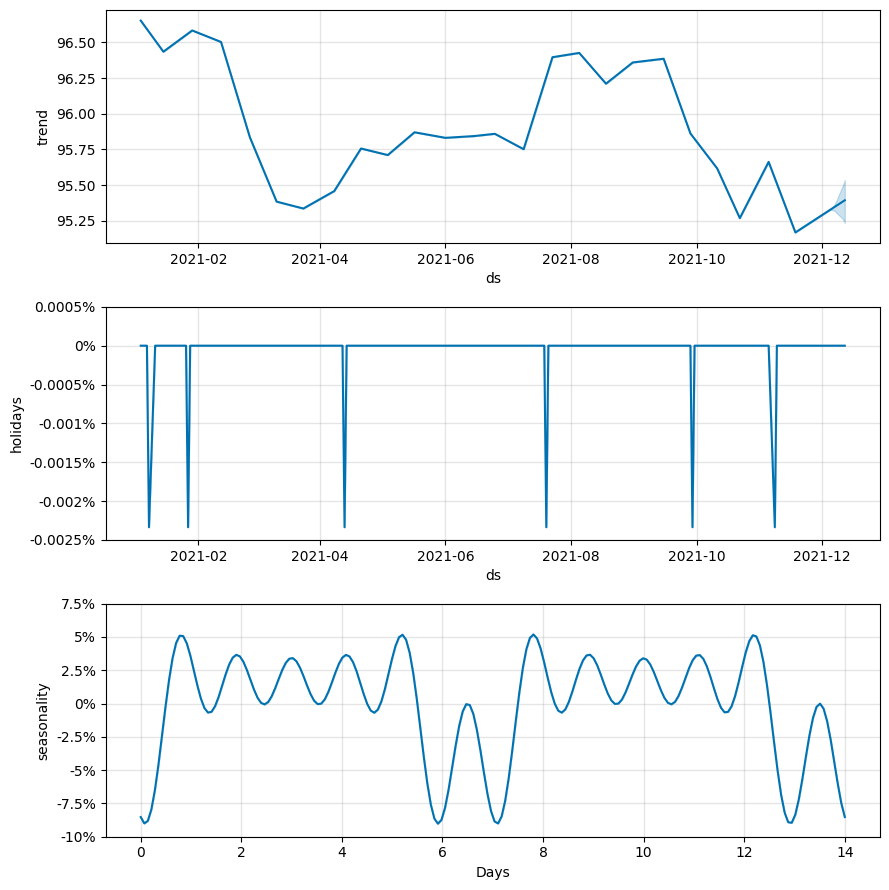

In [ ]:
%%time
# Models tuning
if is_Prophet:
    for period_days in [4, 5, 7, 14]:
        for fourier_order_seasonality in [3, 12]:
            result, _ = prophet_modeling(result,
                                         cryptocurrency,
                                         train_ts,
                                         valid_ts,
                                         holidays_df,
                                         period_days,
                                         fourier_order_seasonality,
                                         forecasting_days,
                                         f'{period_days}_days_{fourier_order_seasonality}_order',
                                         'valid')

In [ ]:
# Get datasets
if is_ARIMA:
    train_ts, valid_ts, test_ts, train_valid_ts = get_train_valid_test_ts(df2.copy(), forecasting_days, target='Close')

Origin dataset has 252 rows and 2 features
Get training dataset with 232 rows
Get validation dataset with 10 rows
Get test dataset with 10 rows


In [ ]:
def acf_pacf_draw(df, lag_num=40, acf=True, pacf=True, title="", ylim=1):
    # Draw plots named title with ACF and PACF for dataframe df

    num_plots = 1+int(acf)+int(pacf)
    fig, ax = plt.subplots(1,num_plots,figsize=(12,6))
    # 'Original Series'
    ax[0].plot(df.values.squeeze())

    if acf:
        # ACF drawing
        plot_acf(df.values.squeeze(), lags=lag_num, ax=ax[1])
        ax[1].set(ylim=(-ylim, ylim))

        if pacf:
            # PACF drawing
            plot_pacf(df.values.squeeze(), lags=lag_num, ax=ax[2])
            ax[2].set(ylim=(-ylim, ylim))

    elif pacf:
        # PACF drawing
        plot_pacf(df.values.squeeze(), lags=lag_num, ax=ax[1])
        ax[1].set(ylim=(-ylim, ylim))

    fig.suptitle(title)
    plt.show()

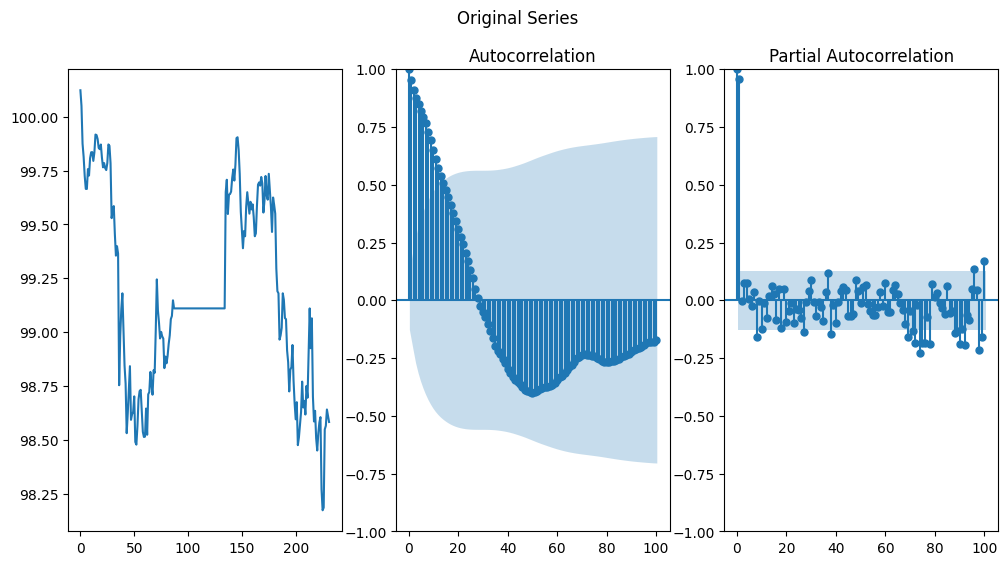

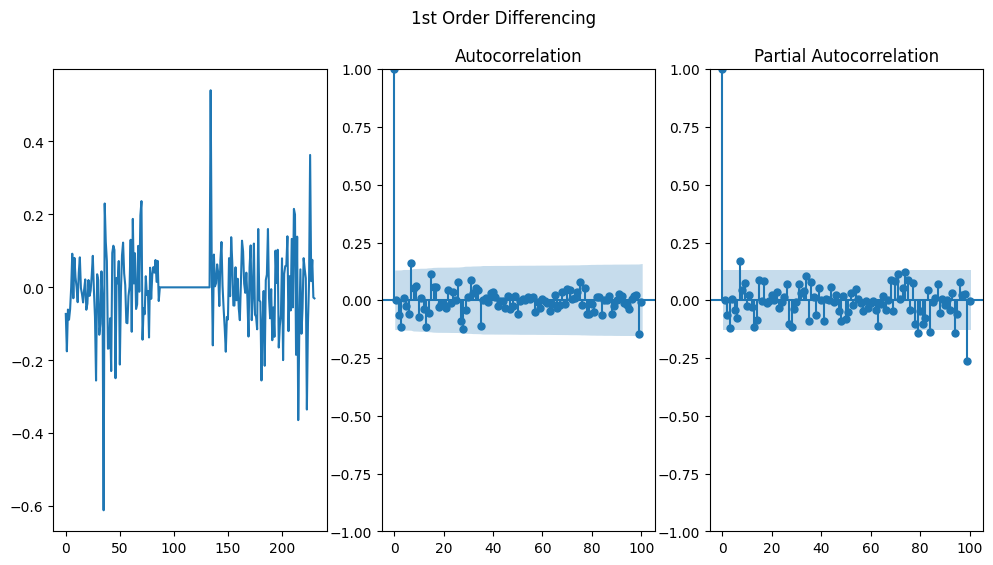

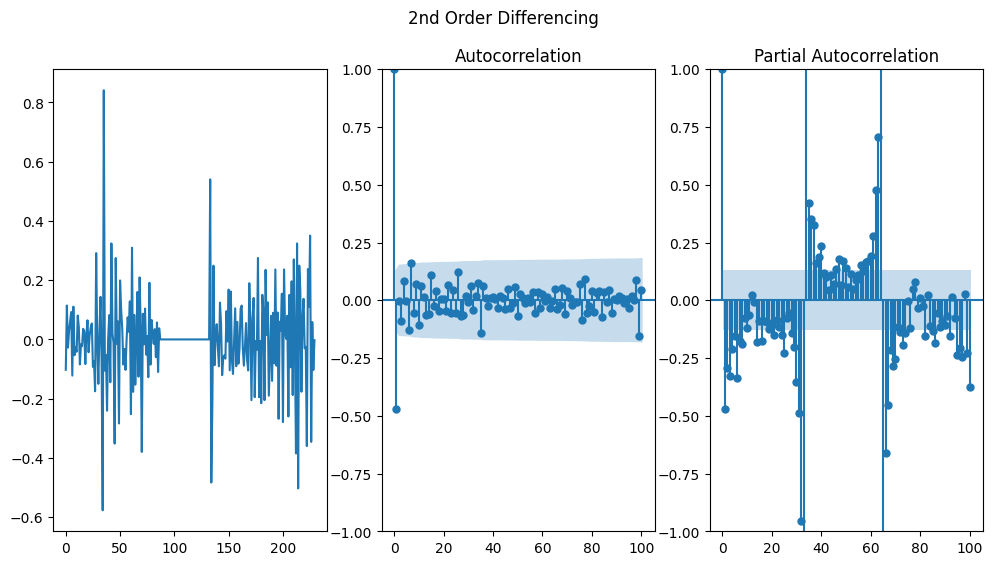

In [ ]:
if is_ARIMA:
    # ACF and PACF
    lag_num = 100
    acf_pacf_draw(train_ts['y'], lag_num, True, True, 'Original Series')
    acf_pacf_draw(train_ts['y'].diff().dropna(), lag_num, True, True, '1st Order Differencing')
    acf_pacf_draw(train_ts['y'].diff().diff().dropna(), lag_num, True, True, '2nd Order Differencing')

In [ ]:
d = 1

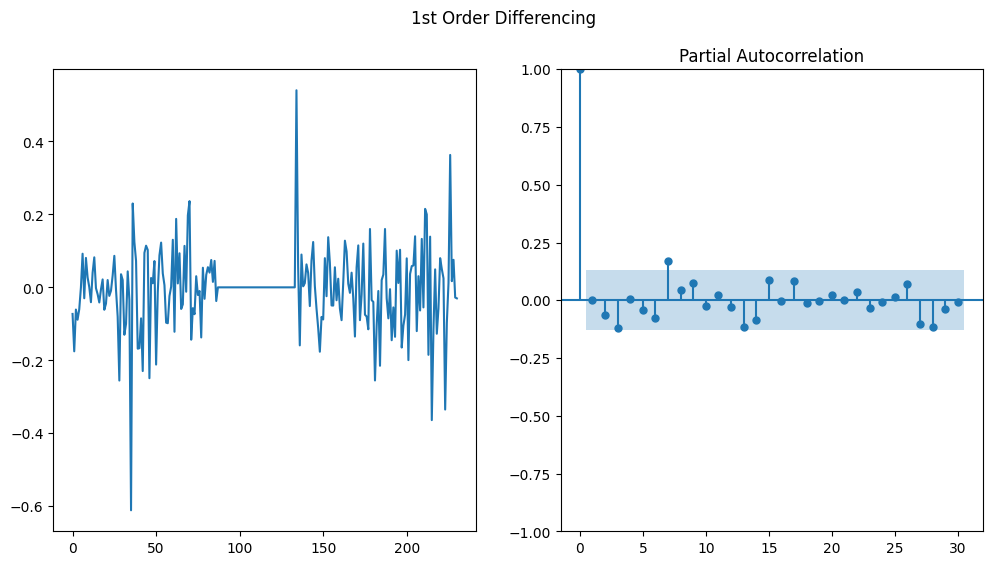

In [ ]:
# PACF drawing
if is_ARIMA:
    acf_pacf_draw(train_ts['y'].diff().dropna(), 30, False, True, '1st Order Differencing', 1)

In [ ]:
p = 0

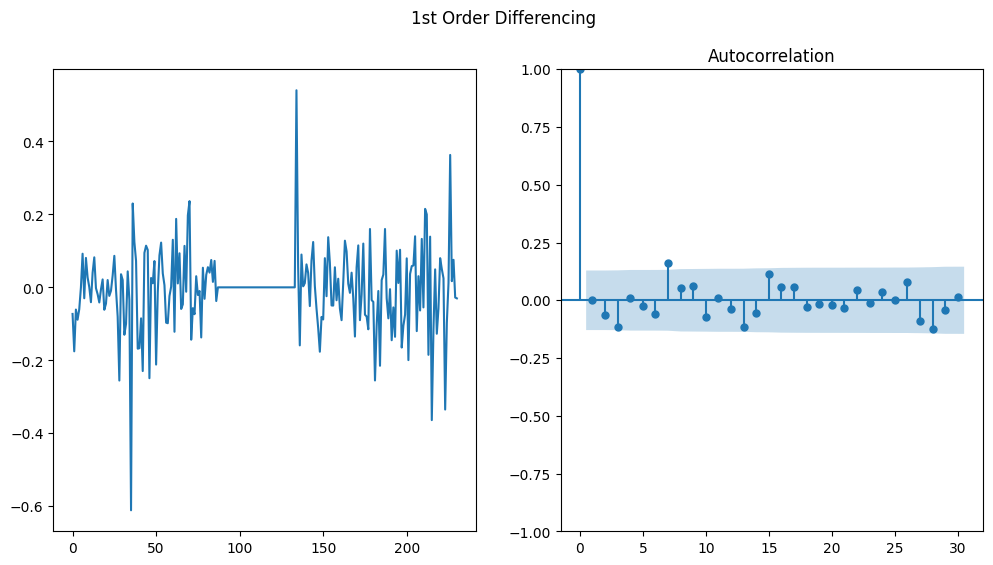

In [ ]:
# ACF drawing
if is_ARIMA:
    acf_pacf_draw(train_ts['y'].diff().dropna(), 30, True, False, '1st Order Differencing', 1)

In [ ]:
q = 0

In [ ]:
def arima_fit(df, col, order=(1,1,1)):
    # ARIMA model fitting for series df[col]

    model = sm.tsa.arima.ARIMA(df[col].values.squeeze(), order=order)
    model = model.fit()
    return model

In [ ]:
if is_ARIMA:
    # ARIMA Model tuning
    model = arima_fit(train_ts, 'y', order=(p,d,q))
    print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  232
Model:                 ARIMA(0, 1, 0)   Log Likelihood                 182.675
Date:                Mon, 10 Apr 2023   AIC                           -363.351
Time:                        13:09:27   BIC                           -359.908
Sample:                             0   HQIC                          -361.962
                                - 232                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0120      0.001     22.324      0.000       0.011       0.013
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               423.05
Prob(Q):                              0.99   Pr

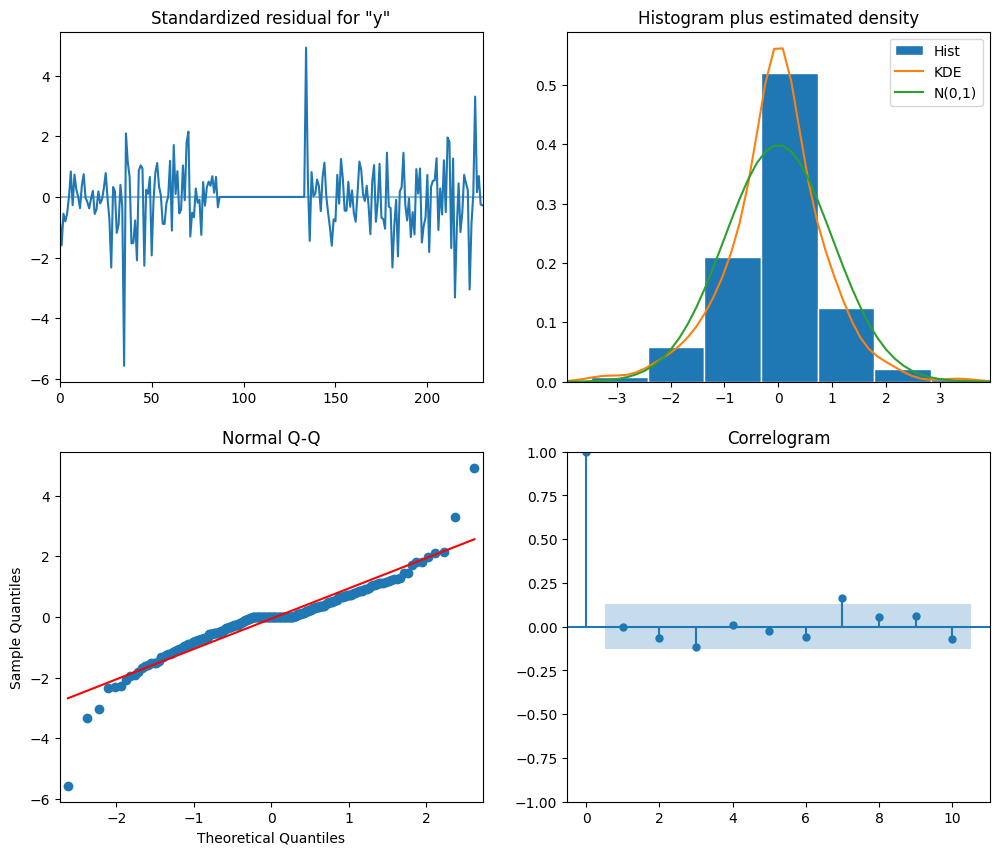

In [ ]:
if is_ARIMA:
    # ARIMA model diagnostics
    fig = model.plot_diagnostics(figsize=(12,10))
    plt.show()

In [ ]:
def get_residual_errors(model):
    # Calculation and drawing the plot residual errors for ARIMA model
    residuals = pd.DataFrame(model.resid)
    fig, ax = plt.subplots(1,2, figsize=(12,6))
    residuals.plot(title="Residuals", ax=ax[0])
    residuals.plot(kind='kde', title='Density', ax=ax[1])
    plt.show()

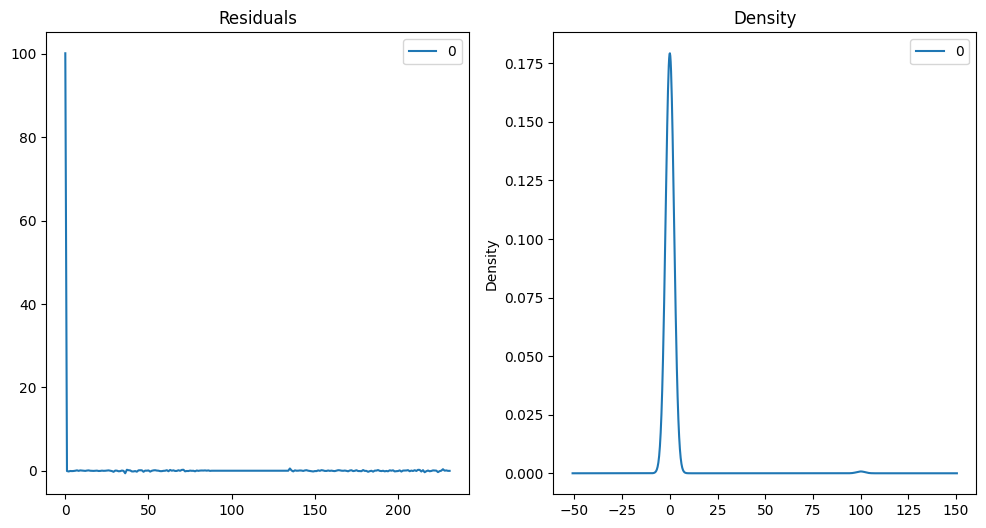

In [ ]:
if is_ARIMA:
    # Plot residual errors
    get_residual_errors(model)

In [ ]:
def arima_forecasting(result, model, params, name_model, df, type_data):
    # Data df (validation or test) forecasting on the num days by the model
    # with params and save metrics to result

    ypred = model.forecast(steps=len(df))

    n = len(result)
    result.loc[n,'name_model'] = name_model
    result.loc[n,'type_data'] = type_data
    result.at[n,'params'] = params
    result.at[n,'ypred'] = ypred
    #result = result_add_metrics(result, n, df['y'], y_pred)

    return result

In [ ]:
%%time
if is_ARIMA:
    # Automatic tuning of the ARIMA model
    model_auto = pm.auto_arima(train_ts['y'].values,
                               start_p=4,        # start p
                               start_q=4,        # start q
                               test='adf',       # use adftest to find optimal 'd'
                               max_p=5, max_q=5, # maximum p and q
                               m=1,              # frequency of series (1 - No Seasonality)
                               d=None,           # let model determine 'd'
                               seasonal=False,   # No Seasonality
                               start_P=0,
                               D=0,
                               start_Q=0,
                               trace=True,
                               error_action='ignore',
                               suppress_warnings=False,
                               stepwise=True     # use the stepwise algorithm outlined in Hyndman and Khandakar (2008)
                                                 # to identify the optimal model parameters.
                                                 # The stepwise algorithm can be significantly faster than fitting all
                                                 # hyper-parameter combinations and is less likely to over-fit the model
                              )

    print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(4,1,4)(0,0,0)[0] intercept   : AIC=-362.703, Time=1.12 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-362.205, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-360.206, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-360.206, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-363.351, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-358.206, Time=0.09 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.539 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  232
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 182.675
Date:                Mon, 10 Apr 2023   AIC                           -363.351
Time:                        13:09:50   BIC                           -359.908
Sample:                             0   HQIC                          -361.962
          

In [ ]:
if is_ARIMA:
    # Get orders of the best model from AutoARIMA
    arima_orders_best = list(model_auto.get_params().get('order'))
    print(f"Optimal parameters are {arima_orders_best}")
    model_auto = arima_fit(train_ts, 'y', order=(arima_orders_best[0],arima_orders_best[1],arima_orders_best[2]))

Optimal parameters are [0, 1, 0]


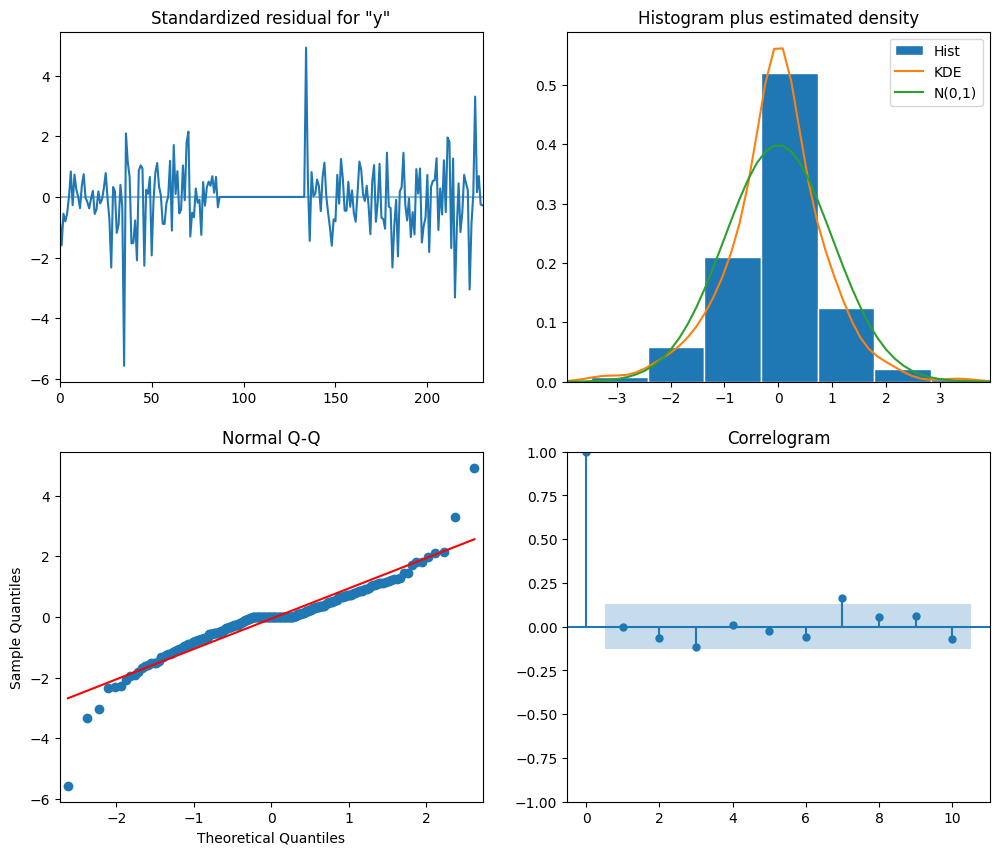

In [ ]:
if is_ARIMA:
    # Best model from AutoARIMA
    fig = model_auto.plot_diagnostics(figsize=(12,10))
    plt.show()

In [ ]:
if is_ARIMA:
    # Valid forecasting and save result
    result = arima_forecasting(result, model_auto, arima_orders_best, 'ARIMA_auto', valid_ts, 'valid')

In [ ]:
# Get datasets
if is_other_ML:
    df2 = get_target_mf(df2, forecasting_days, col='Close')
    train_mf, ytrain_mf, valid_mf, yvalid_mf, test_mf, ytest_mf, train_valid_mf, y_train_valid_mf, starting_point = \
                                    get_train_valid_test_mf(df2.copy(), forecasting_days, target='target')

Origin dataset has 242 rows and 59 features
Get training dataset with 222 rows
Get validation dataset with 10 rows
Get test dataset with 10 rows


In [ ]:
if is_other_ML:
    # Set parameters of models
    models = pd.DataFrame(columns = ['name', 'model', 'param_grid'])

    # Linear Regression
    n = len(models)
    models.loc[n, 'name'] = 'Linear Regression'
    models.at[n, 'model'] = LinearRegression()
    models.at[n, 'param_grid'] = {'fit_intercept' : [True, False]}


    # KNeighbors Regressor
    n = len(models)
    models.loc[n, 'name'] = 'KNeighbors Regressor'
    models.at[n, 'model'] = KNeighborsRegressor()
    models.at[n, 'param_grid'] = {'n_neighbors': [3, 5, 10, 20, 30],
                                  'leaf_size': [10, 20, 30]
                                 }

    # Support Vector Machines
    n = len(models)
    models.loc[n, 'name'] = 'Support Vector Machines'
    models.at[n, 'model'] = SVR()
    models.at[n, 'param_grid'] = {'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
                                  'C': np.linspace(1, 15, 15),
                                  'tol': [1e-3, 1e-4]
                                 }

    # Linear SVC
    n = len(models)
    models.loc[n, 'name'] = 'Linear SVR'
    models.at[n, 'model'] = LinearSVR()
    models.at[n, 'param_grid'] = {'C': np.linspace(1, 15, 15)}


    # Random Forest Classifier
    n = len(models)
    models.loc[n, 'name'] = 'Random Forest Regressor'
    models.at[n, 'model'] = RandomForestRegressor()
    models.at[n, 'param_grid'] = {'n_estimators': [40, 50, 60, 80],
                                  'min_samples_split': [30, 40, 50, 60],
                                  'min_samples_leaf': [10, 12, 15, 20, 50],
                                  'max_features': ['auto'],
                                  'max_depth': [3, 4, 5, 6]
                                 }

    # Bagging Classifier
    n = len(models)
    models.loc[n, 'name'] = 'Bagging Regressor'
    models.at[n, 'model'] = BaggingRegressor()
    models.at[n, 'param_grid'] = {'max_features': np.linspace(0.05, 0.8, 1),
                                  'n_estimators': [3, 4, 5, 6],
                                  'warm_start' : [False]
                                 }

    # XGB Classifier
    n = len(models)
    models.loc[n, 'name'] = 'XGB Regressor'
    models.at[n, 'model'] = xgb.XGBRegressor()
    models.at[n, 'param_grid'] = {'n_estimators': [50, 70, 90],
                                  'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                  'max_depth': [3, 4, 5]
                                 }

    # MLP Classifier
    n = len(models)
    models.loc[n, 'name'] = 'MLP Regressor'
    models.at[n, 'model'] = MLPRegressor()
    models.at[n, 'param_grid'] = {'hidden_layer_sizes': [i for i in range(2,5)],
                                  'solver': ['lbfgs', 'sgd'],
                                  'learning_rate': ['adaptive'],
                                  'learning_rate_init': [0.001, 0.01],
                                  'max_iter': [1000]
                                 }
models

,name,model,param_grid
0,Linear Regression,LinearRegression(),"{'fit_intercept': [True, False]}"
1,KNeighbors Regressor,KNeighborsRegressor(),"{'n_neighbors': [3, 5, 10, 20, 30], 'leaf_size..."
2,Support Vector Machines,SVR(),"{'kernel': ['linear', 'poly', 'rbf', 'sigmoid'..."
3,Linear SVR,LinearSVR(),"{'C': [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0,..."
4,Random Forest Regressor,RandomForestRegressor(),"{'n_estimators': [40, 50, 60, 80], 'min_sample..."
5,Bagging Regressor,BaggingRegressor(),"{'max_features': [0.05], 'n_estimators': [3, 4..."
6,XGB Regressor,"XGBRegressor(base_score=None, booster=None, ca...","{'n_estimators': [50, 70, 90], 'learning_rate'..."
7,MLP Regressor,MLPRegressor(),"{'hidden_layer_sizes': [2, 3, 4], 'solver': ['..."


In [ ]:
def model_prediction(result, models, train_features, valid_features, train_labels, valid_labels):
    # Models training and data prediction for all models from DataFrame models
    # Saving results for validation dataset into dataframe result

    def calc_add_score(res, n, type_score, list_true, list_pred, feature_end):
        # Calculation score with type=type_score for list_true and list_pred
        # Adding score into res.loc[n,...]
        res.loc[i, type_score + feature_end] = calc_metrics(type_score, list_true, list_pred)
        return res

    # Results
    model_all = []

    for i in range(len(models)):
        # Training
        print(f"Tuning model '{models.loc[i, 'name']}'")
        model = GridSearchCV(models.at[i, 'model'], models.at[i, 'param_grid'])
        model.fit(train_features, train_labels)
        model_all.append(model)
        print(f"Best parameters: {model.best_params_}\n")

        # Prediction
        ypred = model.predict(valid_features)

        # Scoring and saving results into the main dataframe result
        n = len(result)
        result.loc[n,'name_model'] = f"{models.loc[i, 'name']}"
        result.loc[n,'type_data'] = "valid"
        result.at[n,'params'] = model.best_params_
        result.at[n,'ypred'] = ypred
        #result = result_add_metrics(result, n, valid_labels, valid_pred)

    return result, model_all

In [ ]:
%%time
if is_other_ML:
    # Models tuning and the forecasting
    result, model_all = model_prediction(result, models, train_mf, valid_mf, ytrain_mf, yvalid_mf)

Tuning model 'Linear Regression'
Best parameters: {'fit_intercept': False}

Tuning model 'KNeighbors Regressor'
Best parameters: {'leaf_size': 10, 'n_neighbors': 5}

Tuning model 'Support Vector Machines'
Best parameters: {'C': 1.0, 'kernel': 'rbf', 'tol': 0.0001}

Tuning model 'Linear SVR'
Best parameters: {'C': 1.0}

Tuning model 'Random Forest Regressor'
Best parameters: {'max_depth': 5, 'max_features': 'auto', 'min_samples_leaf': 15, 'min_samples_split': 30, 'n_estimators': 50}

Tuning model 'Bagging Regressor'
Best parameters: {'max_features': 0.05, 'n_estimators': 6, 'warm_start': False}

Tuning model 'XGB Regressor'
Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 70}

Tuning model 'MLP Regressor'
Best parameters: {'hidden_layer_sizes': 4, 'learning_rate': 'adaptive', 'learning_rate_init': 0.001, 'max_iter': 1000, 'solver': 'lbfgs'}

CPU times: user 4min 45s, sys: 1.79 s, total: 4min 46s
Wall time: 4min 29s


In [ ]:
def recovery_prediction(y, starting_point):
    # Recovering prediction of multi-factors model for shifted col_diff to col in the dataframe df
    # y has type np.array
    # starting_point is dictionary with start values for the recovering data
    # Returns y (np.array) with recovering data

    return np.insert(y, 0, starting_point).cumsum()[1:]

In [ ]:
def result_recover_and_metrics(result, df_ts, type_data, start_points):
    # Recovering prediction: from shifted_Close_diff to Close
    # Calculation metrics for recovering ypred forecasting for all models in result
    # ypred real is from df_ts['y']
    # start points value for the recovering is from dictionary start_points
    # type_data = 'valid' or 'test'

    for i in range(len(result)):
        if (result.loc[i, 'type_data']==type_data) and (result.loc[i, 'mape'] is np.nan):
            ypred = result.loc[i, 'ypred']

            # Recovering ypred for multi-factors models
            if not (str(result.loc[i, 'type_model']) in ['Prophet', 'ARIMA']):
                # Multi-factors model
                # Get start points value for the recovering
                start_point_value = start_points['valid_start_point'] if type_data=='valid' else start_points['test_start_point']
                # Recovering prediction
                ypred = recovery_prediction(ypred, start_point_value)

            # Calculation metrics
            result = result_add_metrics(result, i, df_ts['y'], ypred)

    return result

In [ ]:
# Dispay and save all results for validation dataset
if len(result) > 0:

    # Get type of each model
    result['type_model'] = result['name_model'].str.split('_').str[0]

    # Calculation metrics for recovering prediction ypred for validation dataset by all models
    result = result_recover_and_metrics(result, valid_ts, 'valid', starting_point)
    display(result[['name_model', 'type_data', 'r2_score', 'rmse', 'mape']].sort_values(by=['type_data', 'mape', 'rmse'], ascending=True))

    # Save results
    num_models = len(result[result['type_data']=='valid']['name_model'].unique().tolist())
    print(f"Number of models built - {num_models}")
    result.to_csv(f'result_of_{num_models}_models_for_forecasting_days_{forecasting_days}.csv')
else:
    print('There are no tuned models!')

,name_model,type_data,r2_score,rmse,mape
8,ARIMA_auto,valid,-0.06498,0.102528,0.090493
0,Prophet_4_days_3_order,valid,-0.405735,0.117795,0.097029
1,Prophet_4_days_12_order,valid,-0.40642,0.117823,0.097062
2,Prophet_5_days_3_order,valid,-0.528261,0.122821,0.103281
6,Prophet_14_days_3_order,valid,-0.457777,0.119955,0.103727
3,Prophet_5_days_12_order,valid,-0.570462,0.124505,0.1043
13,Random Forest Regressor,valid,-5.191625,0.247215,0.232926
14,Bagging Regressor,valid,-9.653321,0.324277,0.283827
9,Linear Regression,valid,-10.142485,0.331638,0.306051
11,Support Vector Machines,valid,-14.659633,0.393155,0.360574


Number of models built - 17


In [ ]:
def get_model_opt(name_model, params):
    # Model tuning for the name_model

    print(name_model)
    if name_model=='Linear Regression':
        model = LinearRegression(**params)

    elif name_model=='KNeighbors Regressor':
        model = KNeighborsRegressor(**params)

    elif name_model=='Support Vector Machines':
        model = SVR(**params)

    elif name_model=='Linear SVR':
        model = LinearSVR(**params)

    elif name_model=='Random Forest Regressor':
        model = RandomForestRegressor(**params)

    elif name_model=='Bagging Regressor':
        model = BaggingRegressor(**params)

    elif name_model=='MLP Regressor':
        model = MLPRegressor(**params)

    elif name_model=='XGB Regressor':
        model = xgb.XGBRegressor(**params)

    else: model = None

    return model

In [ ]:
def get_params_optimal_model(result, main_metrics):
    # Get parameters of the optimal model from dataframe result by main_metrics

    # Set the data type to float (just in case)
    result[main_metrics] = result[main_metrics].astype('float')

    # Choose the optimal model
    opt_result = result[result['type_data']=='valid'].reset_index(drop=True)
    if main_metrics=='r2_score':
        opt_model = opt_result.nlargest(1, main_metrics)
    else:
        # 'mape' or 'rmse'
        opt_model = opt_result.nsmallest(1, main_metrics)
    display(opt_model[['name_model', 'r2_score', 'rmse', 'mape', 'params']])

    # Get parameters of the optimal model
    opt_name_model = opt_model['name_model'].tolist()[0]
    opt_type_model = opt_model['type_model'].tolist()[0]
    opt_params_model = opt_model['params'].tolist()[0]
    print(f'Optimal model by metrics "{main_metrics}" is "{opt_name_model}" with type "{opt_type_model}" parameters {opt_params_model}')

    return opt_name_model, opt_type_model, opt_params_model

In [ ]:
def model_training_forecasting(result, df, y, test, ytest,
                               name_model, type_model, params, type_test='1'):
    # Model training for df and y
    # Forecasting ypred
    # type_model = 'Prophet' or "ARIMA" or 'Other ML'
    # type_test = '1' (with find optimal parameters by GridSearchCV)
    # type_test = '2' (with optimal parameters - without GridSearchCV)
    # return params and metrics in the dataframe result

    if type_model=='Prophet':
        season_days_optimal = params[0]
        fourier_order_seasonality_optimal = params[1]
        model_opt = None
        _, ypred = prophet_modeling(result,
                                    cryptocurrency,
                                    df,
                                    test,
                                    holidays_df,
                                    season_days_optimal,
                                    fourier_order_seasonality_optimal,
                                    forecasting_days,
                                    f'{type_model}_optimal',
                                    'test')
    elif type_model=='ARIMA':
        season_days_optimal = params[0]
        fourier_order_seasonality_optimal = params[1]
        model_opt = None

        # Training ARIMA optimal model for training+valid dataset
        df['y'] = y
        model_opt = arima_fit(df, 'y', order=(params[0],params[1],params[2]))

        # Model diagnostics
        fig = model_opt.plot_diagnostics(figsize=(12,10))
        plt.show()

        # Plot residual errors
        get_residual_errors(model_opt)

        # Test forecasting and save result
        ypred = model_opt.forecast(steps=len(test))

    else:
        # Other ML model
        # Training ML optimal model for training+valid dataset
        print(f"Tuning model '{name_model}'")
        models_opt_number = models[models['name']==name_model].index.tolist()[0]
        #print(f"Model - {models.at[models_opt_number,'model']} with parameters {params}")
        if type_test=='1':
            model_opt = GridSearchCV(models.at[models_opt_number,'model'], models.at[models_opt_number,'param_grid'])
        else:
            # type_test=='2'
            model_opt = get_model_opt(models.at[models_opt_number,'name'], params)
        model_opt.fit(df, y)

        # Forecasting
        ypred = model_opt.predict(test)


    # Scoring and saving results into the dataframe result
    n = len(result)-1
    result.loc[n,'name_model'] = f"{type_model}_optimal"
    result.loc[n,'type_data'] = "test"
    result.loc[n,'type_model'] = type_model
    result.at[n,'params'] = params
    result.at[n,'ypred'] = ypred
    #result = result_add_metrics(result, n, ytest, ypred)

    return result, model_opt, ypred

In [ ]:
def get_optimal_model_and_forecasting(result, main_metrics, start_points):
    # Choosion the optimal model from dataframe result by main_metrics
    # Tuning optimal model for big dataset train+valid
    # Test forecasting and drawing it
    # Returns the optimal model and it's name


    if len(result) > 0:
        # Get parameters of the optimal model from dataframe result by main_metrics
        opt_name_model, opt_type_model, opt_params_model = get_params_optimal_model(result,
                                                                                    main_metrics)
        # Set datasets for the final tuning and testing by optimal model
        if (opt_type_model=='Prophet') or (opt_type_model=='ARIMA'):
            train_valid = train_valid_ts.copy()
            y_train_valid = train_valid_ts['y'].copy()
            test = test_ts.copy()
            ytest = test_ts['y'].copy()

        else:
            # Multi-factors ML models
            train_valid = train_valid_mf.copy()
            y_train_valid = y_train_valid_mf.copy()
            test = test_mf.copy()
            ytest = ytest_mf.copy()

        # Optimal model training for train+valid and test forecasting
        result, model_opt, ypred = model_training_forecasting(result, train_valid, y_train_valid,
                                                              test, ytest,
                                                              opt_name_model, opt_type_model,
                                                              opt_params_model, '1')

        # Calculation metrics for recovering prediction ypred for test dataset by the optimal model
        result = result_recover_and_metrics(result, test_ts, 'test', start_points)

        # Drawing plot for prediction for the test data
        if not ((opt_type_model=='Prophet') or (opt_type_model=='ARIMA')):
            # Recovery values "Close"
            ytest_plot = recovery_prediction(ytest.values, start_points['test_start_point'])
            ypred_plot = recovery_prediction(ypred, start_points['test_start_point'])
        else:
            ytest_plot = ytest.copy()
            ypred_plot = ypred.copy()

        # Drawing
        plt.figure(figsize=(12,8))
        x = np.arange(len(ytest_plot))
        plt.scatter(x, ytest_plot, label = "Target test data", color = 'g', s=100)
        plt.scatter(x, ypred_plot, label = f"{opt_name_model} forecasting", color = 'r', s=50)
        plt.title(f'Forecasting of test data using the "{opt_name_model}" model, which is optimal for "{main_metrics}" metrics')
        plt.ylim(0)
        plt.legend(loc='lower right')
        plt.grid(True)

        return opt_name_model

In [ ]:
result

,name_model,type_data,r2_score,rmse,mape,params,ypred,type_model
0,Prophet_4_days_3_order,valid,-0.405735,0.117795,0.097029,"[4, 3]",232 98.575289 233 98.577058 234 98.56...,Prophet
1,Prophet_4_days_12_order,valid,-0.40642,0.117823,0.097062,"[4, 12]",232 98.574505 233 98.576982 234 98.56...,Prophet
2,Prophet_5_days_3_order,valid,-0.528261,0.122821,0.103281,"[5, 3]",232 98.525587 233 98.554097 234 98.58...,Prophet
3,Prophet_5_days_12_order,valid,-0.570462,0.124505,0.1043,"[5, 12]",232 98.527916 233 98.556917 234 98.58...,Prophet
4,Prophet_7_days_3_order,valid,-965.459508,3.088624,2.049721,"[7, 3]",232 98.551889 233 93.634147 234 93.64...,Prophet
5,Prophet_7_days_12_order,valid,-1791.763644,4.206634,2.766218,"[7, 12]",232 98.548469 233 91.868557 234 91.87...,Prophet
6,Prophet_14_days_3_order,valid,-0.457777,0.119955,0.103727,"[14, 3]",232 98.551096 233 98.568989 234 98.59...,Prophet
7,Prophet_14_days_12_order,valid,-5199.74454,7.164832,4.668756,"[14, 12]",232 98.560626 233 87.185190 234 87.19...,Prophet
8,ARIMA_auto,valid,-0.06498,0.102528,0.090493,"[0, 1, 0]","[98.5824966430664, 98.5824966430664, 98.582496...",ARIMA
9,Linear Regression,valid,-10.142485,0.331638,0.306051,{'fit_intercept': False},"[0.03584301052502198, 0.004114595983701452, 0....",Linear Regression


,name_model,r2_score,rmse,mape,params
8,ARIMA_auto,-0.06498,0.102528,0.090493,"[0, 1, 0]"


Optimal model by metrics "r2_score" is "ARIMA_auto" with type "ARIMA" parameters [0, 1, 0]


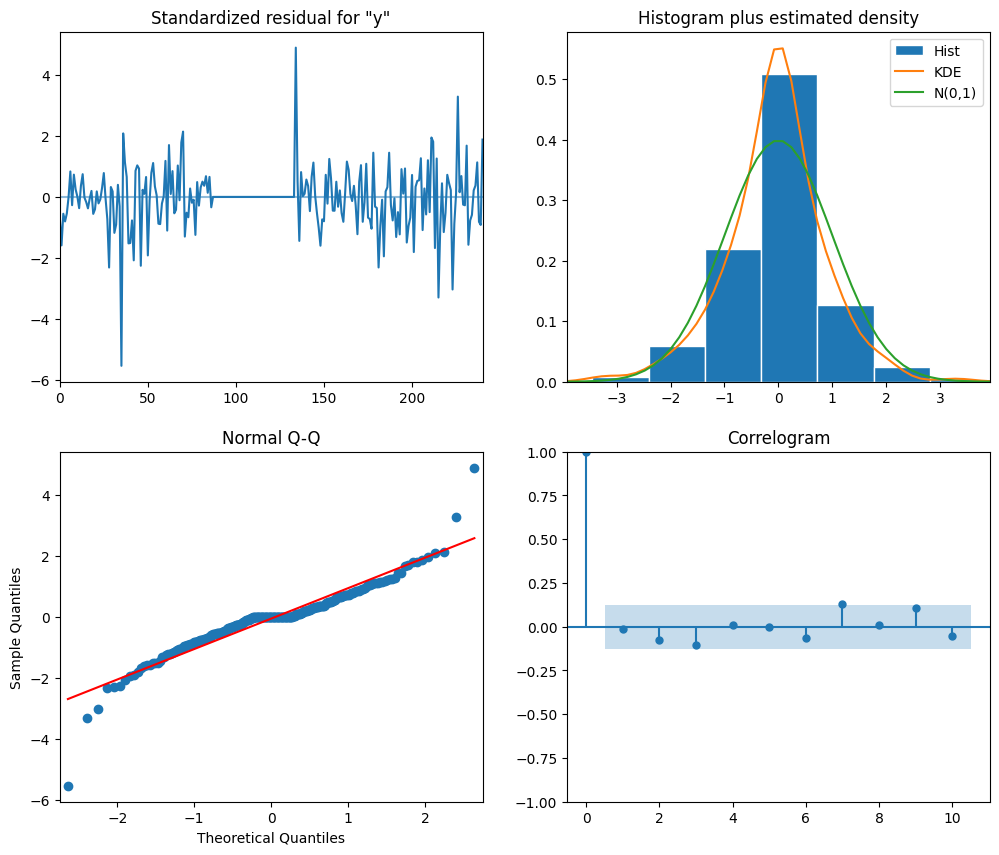

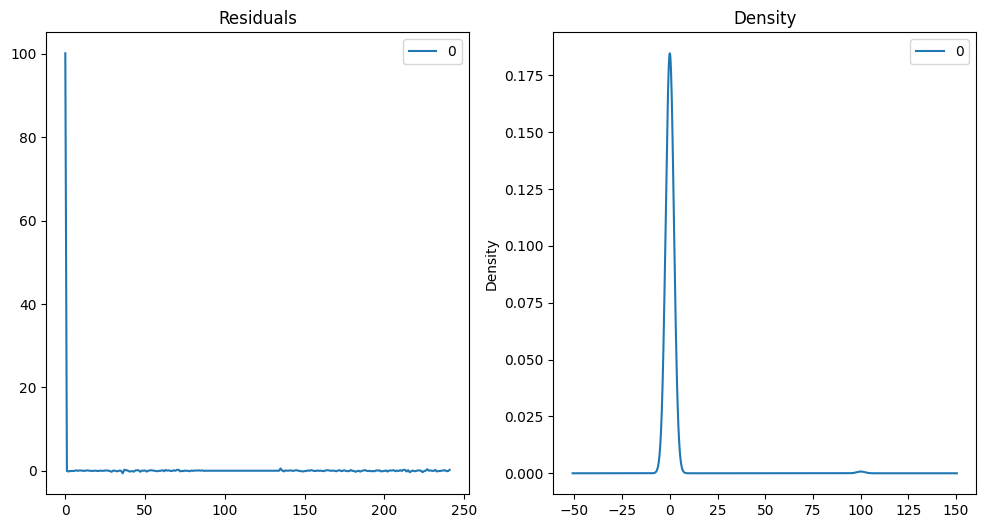

,name_model,r2_score,rmse,mape,params
8,ARIMA_auto,-0.06498,0.102528,0.090493,"[0, 1, 0]"


Optimal model by metrics "rmse" is "ARIMA_auto" with type "ARIMA" parameters [0, 1, 0]


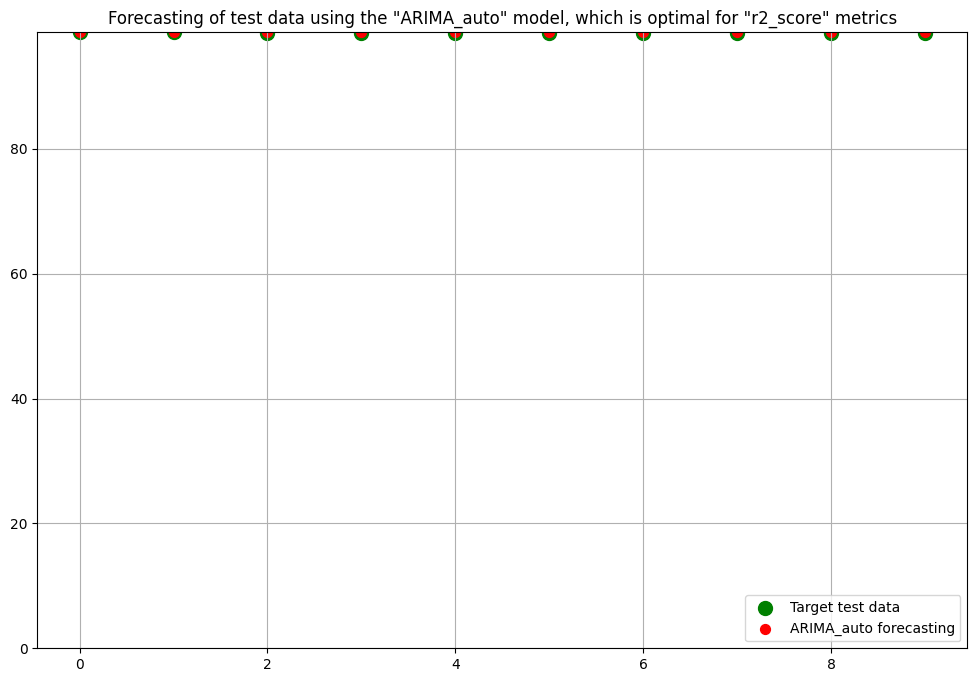

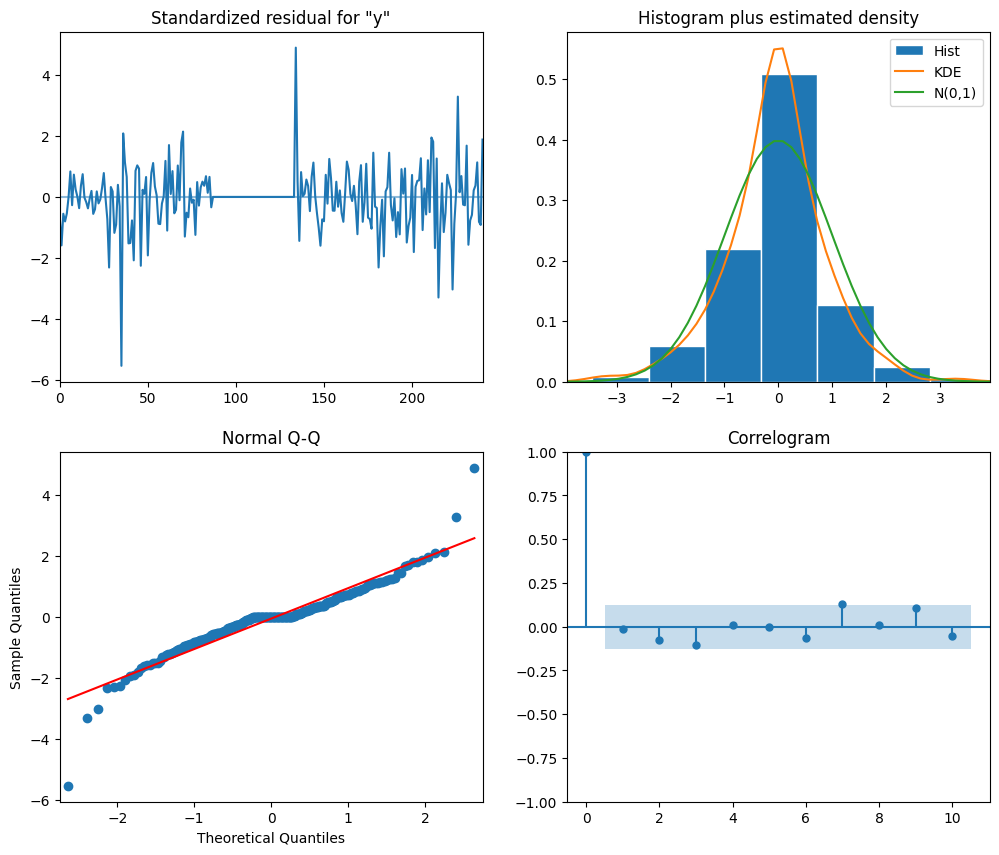

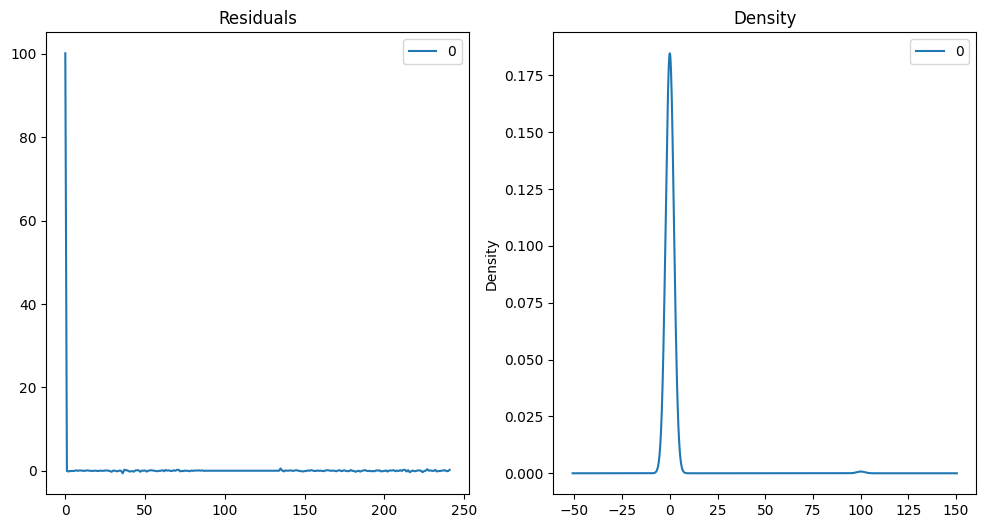

,name_model,r2_score,rmse,mape,params
8,ARIMA_auto,-0.06498,0.102528,0.090493,"[0, 1, 0]"


Optimal model by metrics "mape" is "ARIMA_auto" with type "ARIMA" parameters [0, 1, 0]


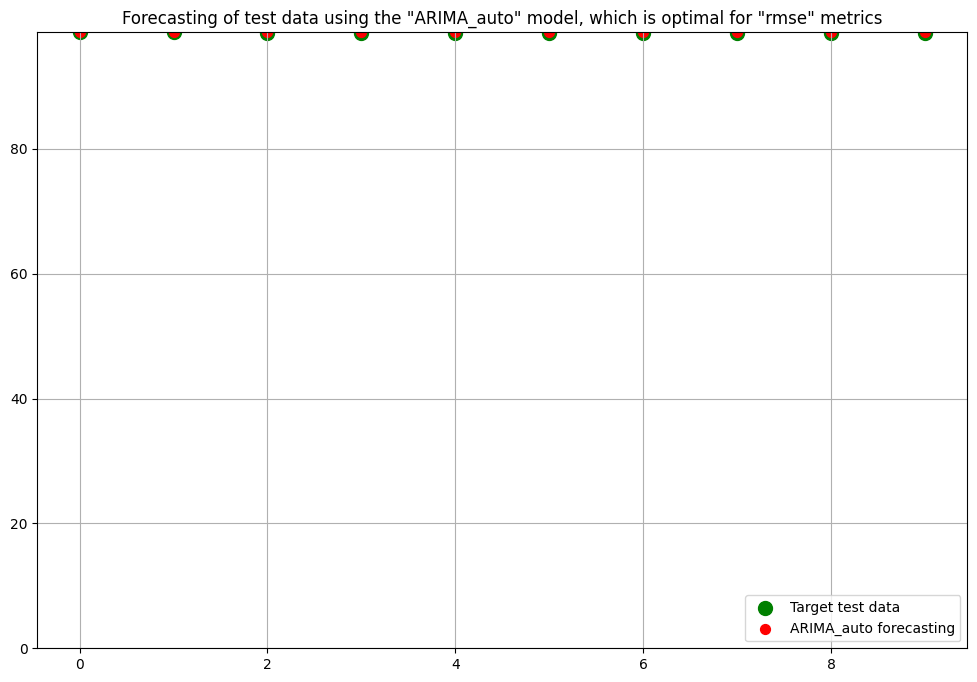

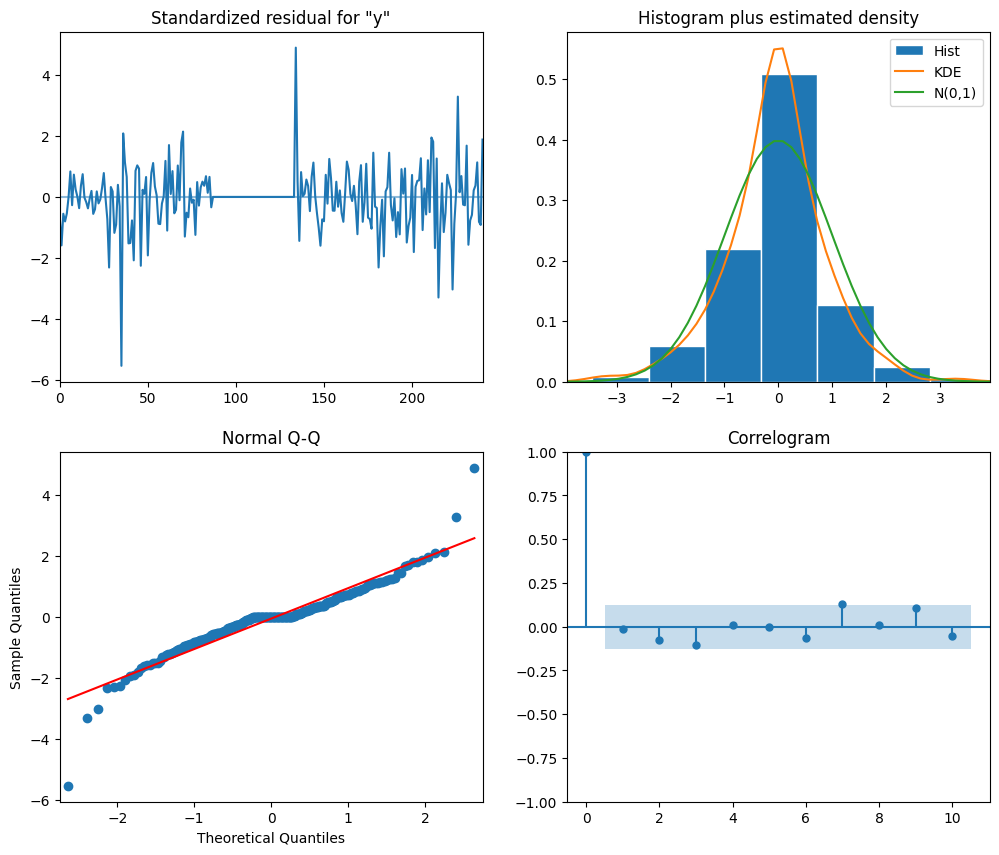

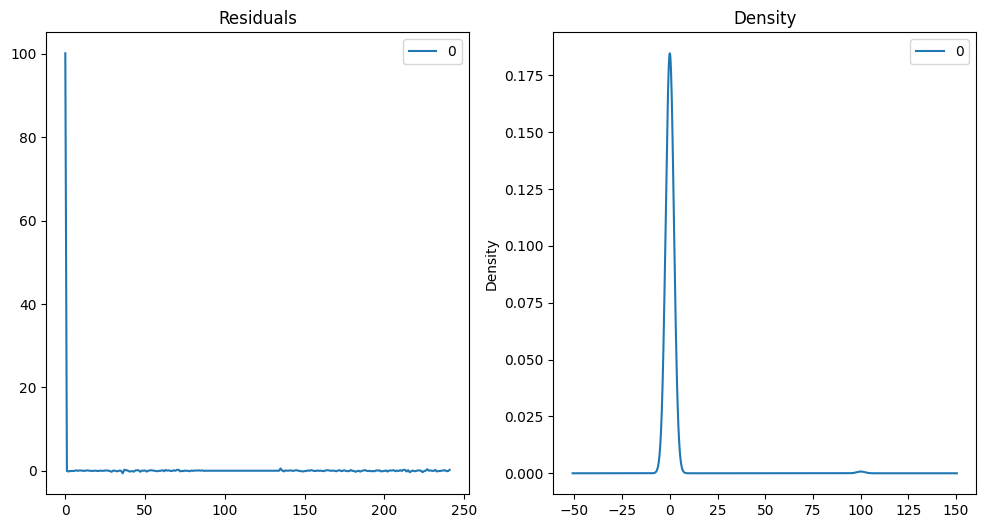

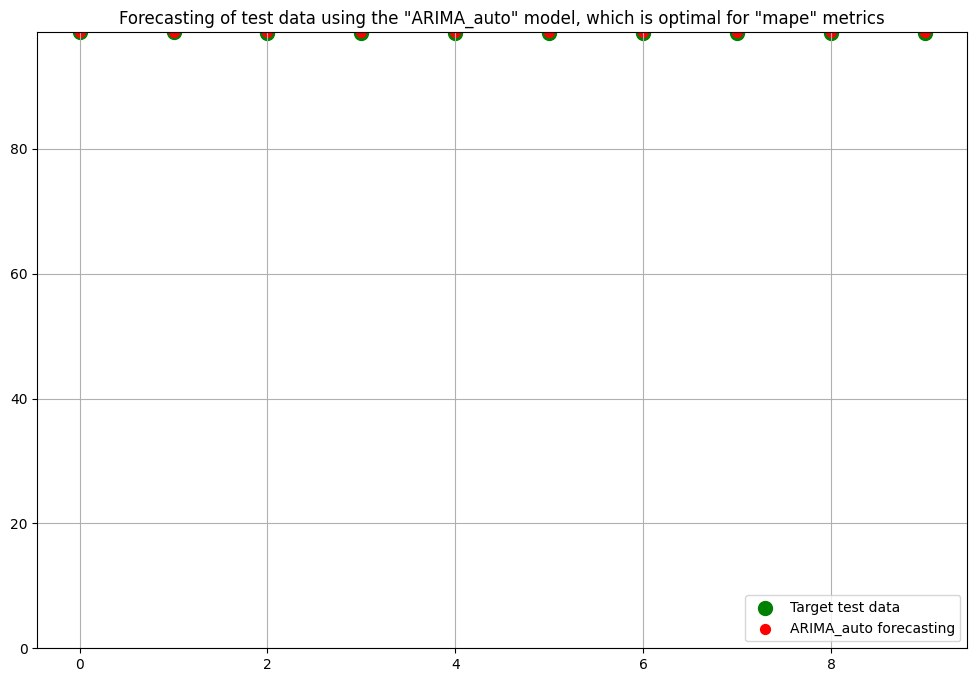

In [ ]:
# Get the optimal model by different metrics
if len(result) > 0:
    for valid_metrics in ['r2_score', 'rmse', 'mape']:
        get_optimal_model_and_forecasting(result, valid_metrics, starting_point)

In [ ]:
# Training ML optimal model for training+valid dataset
# Get parameters of the optimal model from dataframe result (without Time Series models) by main_metrics
if is_other_ML:
    main_metrics = 'r2_score'
    if (len(result) > 0) and (len(models) > 0):
        result_nonTS = result[(result['type_model']!='Prophet') & (result['type_model']!='ARIMA')].reset_index(drop=True)
        opt_name_model2, opt_type_model2, opt_params_model2 = get_params_optimal_model(result_nonTS,
                                                                                main_metrics)

        result, model_opt, ypred = model_training_forecasting(result,
                                                              train_valid_mf,
                                                              y_train_valid_mf,
                                                              test_mf,
                                                              ytest_mf,
                                                              opt_name_model2,
                                                              opt_type_model2,
                                                              opt_params_model2,
                                                              '2')

,name_model,r2_score,rmse,mape,params
4,Random Forest Regressor,-5.191625,0.247215,0.232926,"{'max_depth': 5, 'max_features': 'auto', 'min_..."


Optimal model by metrics "r2_score" is "Random Forest Regressor" with type "Random Forest Regressor" parameters {'max_depth': 5, 'max_features': 'auto', 'min_samples_leaf': 15, 'min_samples_split': 30, 'n_estimators': 50}
Tuning model 'Random Forest Regressor'
Random Forest Regressor
